In [6]:
import dask
import cftime
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import xclimate as xclim

In [174]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='10GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  10GB
walltime: 02:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45871 instead
  warnings.warn(


{'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 45871:128.117.211.162:45871 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:45871/status


In [176]:
# client_cluster[1]

In [ ]:
# xclim.close_dask_cluster(client_cluster)

In [7]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Sending large graph of size",
    category=UserWarning,
    module="distributed.client",
)

# utils

In [8]:
from datetime import timedelta

def split_years_months(da):
    assert 'time' in da.dims, ValueError("da must have a time coordinate")
    assert da.time.size % 12 == 0, ValueError("time coordinate must be a multiple of 12")

    name = da.name
    years  = np.unique(da.time.dt.year.values)
    months = np.unique(da.time.dt.month.values)
    
    # Rechunk time dim contiguously before reshape
    da = da.chunk({'time': -1})
    
    new_shape = (len(years), len(months)) + da.shape[1:]
    new_dims  = ['year', 'month'] + list(da.dims[1:])

    extra_coords = {k: v for k, v in da.coords.items()
                    if 'time' not in v.dims}
    
    return xr.DataArray(
        da.data.reshape(new_shape),   # dask-safe
        dims=new_dims,
        coords={'year': years, 'month': months, **extra_coords}
    ).rename(name)


def combine_years_months(da, freq='MS'):
    name = da.name
    years  = da.year.values   # shape (Y,)
    months = da.month.values  # shape (M,)

    # Build full Y×M time index, then flatten
    yy, mm = np.meshgrid(years, months, indexing='ij')  # both (Y, M)
    time_index = xr.date_range(                         # or pd.date_range if using numpy datetimes
        start=f'{years[0]}-{months[0]:02d}',
        periods=len(years) * len(months),
        freq=freq,
        use_cftime=True
    )

    # Flatten year×month into time, preserve trailing spatial dims
    trailing_dims   = list(da.dims[2:])          # e.g. ['lat', 'lon']
    trailing_shape  = da.shape[2:]
    flat_data = da.data.reshape(len(time_index), *trailing_shape)  # dask-safe

    # Preserve non-(year,month) coords
    extra_coords = {k: v for k, v in da.coords.items()
                    if not any(d in ('year', 'month') for d in v.dims)}

    return xr.DataArray(
        flat_data,
        dims=['time'] + trailing_dims,
        coords={'time': time_index, **extra_coords}
    ).rename(name)


def detrend(da, tcoord):
    if not isinstance(da[tcoord][0].item(), float):
        dat = da.assign_coords(t=(tcoord, np.arange(len(da[tcoord]))))
        coeffs = dat.polyfit(dim='t', deg=1, skipna=True).polyfit_coefficients
        trend = coeffs.sel(degree=1) # per tcoord
        return da - trend * (dat['t'] - dat['t'][0])

    coeffs = da.polyfit(dim=tcoord, deg=1, skipna=True).polyfit_coefficients
    trend = coeffs.sel(degree=1) # per tcoord
    return da - trend * (da[tcoord] - da[tcoord][0])


def detrend_year(da):
    dam = split_years_months(da)
    dam_dt = detrend(dam, 'year')
    return combine_years_months(dam_dt)

In [9]:
from glob import glob


def load_member(v: str, yr: str, mem_str: str) -> xr.DataArray:
    """Open, time-concat, reindex, and mask one ensemble member."""
    files = sorted(
        glob(f'{lens_dir}/{v}/b.e21.BHIST{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc') +
        glob(f'{lens_dir}/{v}/b.e21.BSSP370{bb}.f09_g17.LE2-{yr}.{mem_str}.cam.h0.{v}.*.nc')
    )
    ds = xr.open_mfdataset(
        files,
        parallel=True,
        combine='by_coords',
        data_vars='minimal',
        coords='minimal',
        compat='override',
    )
    return (
        xclim.time_coord.shift_time(ds)
        .sel(time=tperiod)[v]
        .where(om)
    )


xr.set_options(use_new_combine_kwarg_defaults=True)

bb  = 'cmip6'
lens_dir = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1'
lens_starts = [
    '1001', '1021', '1041', '1061', '1081', '1101', '1121',
    '1141', '1161', '1181', '1231', '1251', '1281', '1301'
]

In [10]:
def lin_smooth_weights(n):
    return np.linspace(1, 0, n + 1)[1:]  # t \in (0, 1], excludes t=0


def cos_smooth_weights(n):
    t = np.linspace(0, 1, n + 1)[1:]  # t \in (0, 1], excludes t=0
    return 0.5 * (1 + np.cos(np.pi * t))


def build_relax_param_clim(weights, overlap):
    nyear = len(overlap.year)
    relax_nyear = len(weights)
    return xr.DataArray(
        data=np.concatenate(
            [
                np.stack(12 * [weights], axis=1),
                np.full((nyear - relax_nyear, 12), 0),
            ]
        ),
        coords={"year": overlap.year, "month": overlap.month},
    )


def build_relax_param_time(weights, overlap):
    ntime = len(overlap.time)
    relax_ntime = len(weights)
    return xr.DataArray(
        data=np.concatenate(
            [
                weights,
                np.full(ntime - relax_ntime, 0),
            ]
        ),
        coords={"time": overlap.time},
    )


def build_timeseries(lens, obs, weights):
    return lens + weights * (obs - lens)

In [11]:
def plot_single_gridcell(x, y, z, x_my, y_my, z_my, ilat=50, ilon=50, end_year=2020, tag='SST'):
    fig, axs = plt.subplots(2, 2, figsize=(8, 6), layout='constrained')
    ax = axs.ravel()

    x.sel(time=slice(None, str(end_year))).isel(lat=ilat, lon=ilon).plot(ax=ax[0], label='O(t)', color='tab:blue')
    y.sel(time=slice(None, str(end_year))).isel(lat=ilat, lon=ilon).plot(ax=ax[0], label='M(t)', color='tab:orange')
    z.sel(time=slice(None, str(end_year))).isel(lat=ilat, lon=ilon).plot(ax=ax[0], label=f'{tag}(t)', color='tab:red')
    ax[0].set_title(f'lon = ${x.lon.isel(lon=ilon).item(): 0.1f}$, lat = ${x.lat.isel(lat=ilat).item(): 0.1f}$')
    ax[0].legend(loc='upper right')

    x_my.sel(month=1, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[1], label='O(t)', color='tab:blue', marker='o')
    y_my.sel(month=1, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[1], label='M(t)', color='tab:orange', marker='o')
    z_my.sel(month=1, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[1], label=f'{tag}(t)', color='tab:red', marker='o')
    ax[1].set_title(f'month = 1, lon = ${x.lon.isel(lon=ilon).item(): 0.1f}$, lat = ${x.lat.isel(lat=ilat).item(): 0.1f}$')
    ax[1].legend(loc='upper right')

    x_my.sel(month=6, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[2], label='O(t)', color='tab:blue', marker='o')
    y_my.sel(month=6, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[2], label='M(t)', color='tab:orange', marker='o')
    z_my.sel(month=6, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[2], label=f'{tag}(t)', color='tab:red', marker='o')
    ax[2].set_title(f'month = 6, lon = ${x.lon.isel(lon=ilon).item(): 0.1f}$, lat = ${x.lat.isel(lat=ilat).item(): 0.1f}$')
    ax[2].legend(loc='upper right')

    x_my.sel(month=12, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[3], label='O(t)', color='tab:blue', marker='o')
    y_my.sel(month=12, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[3], label='M(t)', color='tab:orange', marker='o')
    z_my.sel(month=12, year=slice(None, end_year)).isel(lat=ilat, lon=ilon).plot(ax=ax[3], label=f'{tag}(t)', color='tab:red', marker='o')
    ax[3].set_title(f'month = 12, lon = ${x.lon.isel(lon=ilon).item(): 0.1f}$, lat = ${x.lat.isel(lat=ilat).item(): 0.1f}$')
    ax[3].legend(loc='upper right')

    return fig, ax


def plot_regions(x, y, z, regions, region_names, end_time, label, use_cftime=True, **kwargs):
    assert len(regions.keys()) == 8 & len(region_names.keys()) == 8

    if use_cftime:
        time_slice = {'time': slice(None, end_time)}
    else:
        time_slice = {'year': slice(None, end_time)}

    fig, axs = plt.subplots(2, 4, figsize=(13, 5), sharex=True, layout='constrained', dpi=200)
    ax = axs.flatten()

    for i, (name, reg) in enumerate(regions.items()):
        x_reg = x.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()
        y_reg = y.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()
        z_reg = z.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()

        x_reg.plot(ax=ax[i], c='tab:blue', ls='-', label='O(t)', **kwargs)
        y_reg.plot(ax=ax[i], c='tab:orange', ls='-', label='M(t)', **kwargs)
        z_reg.plot(ax=ax[i], c='tab:red', ls='-', label='SST(t)', **kwargs)

        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_title(region_names[name])

    ax[3].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    fig.suptitle(label, fontweight='bold')
    return fig, ax

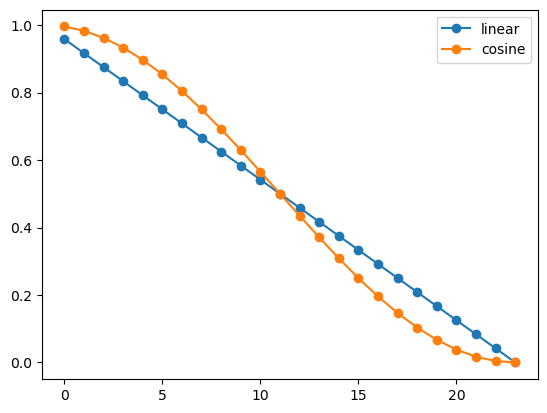

In [72]:
t = np.arange(24)
plt.plot(t, lin_smooth_weights(t.size), marker='o', label='linear')
plt.plot(t, cos_smooth_weights(t.size), marker='o', label='cosine')
plt.legend()

# full time period

In [178]:
tperiod = slice('1980-01', '2100-12')

# masks

In [12]:
ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/AREA/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.AREA.195001-195912.nc')
area = ds.AREA.isel(time=0).drop_vars('time')

ds = xr.open_dataset('/glade/campaign/collections/gdex/data/d651056/CESM2-LE/lnd/proc/tseries/month_1/GPP/b.e21.BHISTcmip6.f09_g17.LE2-1301.006.clm2.h2.GPP.195001-195912.nc')
ds = ds.reindex_like(area, tolerance=1e-3, method='nearest').drop_vars('time')
a = (ds.area * 1e6).assign_attrs({'units': 'm2'})
lf = ds.landfrac
la = a * lf
lm = ~np.isnan(la)
om = ~lm
oa = area.where(om, other=0)

In [48]:
def build_cice_region_masks(lat, lon, region_lon_bnds, lat_bnds, ocean_mask):
    """Build boolean masks for a dictionary of longitude-bounded regions."""
    region_masks = {}

    for name, lon_bnds in region_lon_bnds.items():
        if lon_bnds[0] > lon_bnds[1]:
            in_region = (
                (lat > lat_bnds[0])
                & (lat <= lat_bnds[1])
                & ((lon > lon_bnds[0]) | (lon <= lon_bnds[1]))
            )
        elif lon_bnds[0] == -1:
            in_region = (
                (lat > lat_bnds[1])
                & (lon > lon_bnds[0])
                & (lon <= lon_bnds[1])
            )
        elif lon_bnds[0] == -2:
            in_region = (
                (lat < lat_bnds[1])
                & (lon > lon_bnds[0])
                & (lon <= lon_bnds[1])
            )
        else:
            in_region = (
                (lat > lat_bnds[0])
                & (lat <= lat_bnds[1])
                & (lon > lon_bnds[0])
                & (lon <= lon_bnds[1])
            )

        region_masks[name] = in_region.rename(name).where(ocean_mask, other=0)

    return region_masks

In [49]:
CICE_NH_LAT_BNDS = [67, 80]
CICE_NH_REGIONS = {
    'gin': [335, 18],
    'barents': [18, 57],
    'kara': [57, 103],
    'laptev': [103, 143],
    'eastsib': [143, 180],
    'chukchi': [180, 200],
    'beaufort': [200, 235],
    'okhotsk': [235, 287],
    'baffin': [287, 320],
    'central': [-1, 360],
}

In [50]:
CICE_SH_LAT_BNDS = [-90, -55]
CICE_SH_REGIONS = {
    'indian': [20, 90],
    'weddel': [90, 160],
    'amundbell': [160, 230],
    'ross': [230, 300],
    'westpac': [300, 360],
    'pan': [-2, 360],
}

In [51]:
lat = area.lat
lon = area.lon
cice_iregmask = xr.zeros_like(area, dtype=np.int16)
region_ids = {}

cice_nh_regions = build_cice_region_masks(lat, lon, CICE_NH_REGIONS, CICE_NH_LAT_BNDS, om)
cice_sh_regions = build_cice_region_masks(lat, lon, CICE_SH_REGIONS, CICE_SH_LAT_BNDS, om)


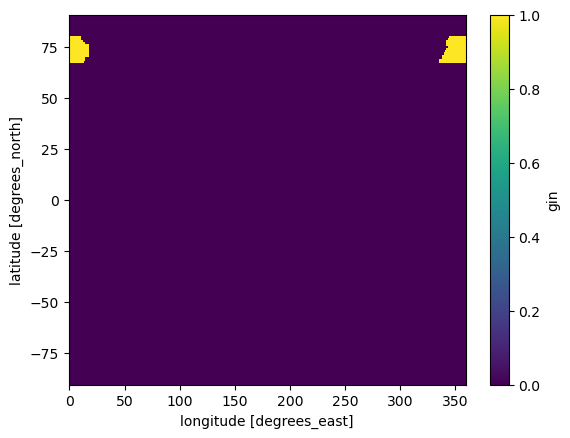

In [52]:
cice_nh_regions['gin'].plot()

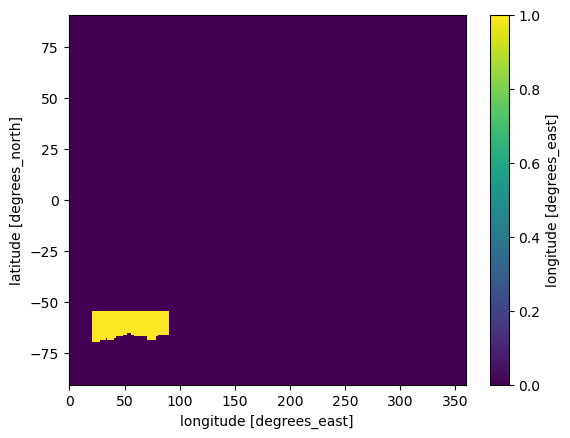

In [53]:
cice_sh_regions['indian'].plot()

# load HadOI

In [180]:
hadbc = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/atm/cam/sst/sst_HadOIBl_bc_0.9x1.25_1850_2022_c241003.nc')
obs_sst = hadbc.SST_cpl_prediddle.sel(time=tperiod).reindex_like(area, tolerance=1e-3, method='nearest')
obs_cice = hadbc.ice_cov_prediddle.sel(time=tperiod).reindex_like(area, tolerance=1e-3, method='nearest')

# SST

## load LENS2

In [5]:
v   = 'SST'

members = []
tags = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        # members.append(load_member(v, yr, str(im + 1).zfill(3)))
        tags.append(yr+'-'+str(im + 1).zfill(3))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            # members.append(load_member(v, yr, str(i).zfill(3)))
            tags.append(yr+'-'+str(i).zfill(3))
        print()

# lens_sst = (
#     xr.concat(members, dim='ens')
#     .assign_coords(ens=np.arange(1, 51), ens_name=('ens', tags))
#     .assign_attrs(units='deg_C')
#     - 273.15
# )
# lens_sst = lens_sst.chunk({'time': -1})

- 1001
- 1021
- 1041
- 1061
- 1081
- 1101
- 1121
- 1141
- 1161
- 1181
- 1231
001 002 003 004 005 006 007 008 009 010 
- 1251
001 002 003 004 005 006 007 008 009 010 
- 1281
001 002 003 004 005 006 007 008 009 010 
- 1301
001 002 003 004 005 006 007 008 009 010 


## compute terms

In [182]:
member = 15
lens_sst_mem = lens_sst.sel(ens=member).persist()

overlap_tperiod = slice('2015-01', '2021-12')

lens_sst_overlap = lens_sst_mem.sel(time=overlap_tperiod)
obs_sst_overlap = obs_sst.sel(time=overlap_tperiod).assign_coords(time=lens_sst_overlap.time)

lens_sst_overlap_my = split_years_months(lens_sst_overlap)
obs_sst_overlap_my = split_years_months(obs_sst_overlap)

In [183]:
year = lens_sst_overlap_my.year
nyear = len(year)
relax_nyear = 2

ntime = len(lens_sst_overlap.time)
relax_ntime = 12 * 1

## using cosine smoothing with monthly climatology

In [94]:
relax_weights_clim = cos_smooth_weights(relax_nyear + 1)
relax_param_clim_my = build_relax_param_clim(relax_weights_clim, lens_sst_overlap_my)
sst_overlap_clim_my = build_timeseries(lens_sst_overlap_my, obs_sst_overlap_my, relax_param_clim_my).compute()
sst_overlap_clim = combine_years_months(sst_overlap_clim_my).compute()

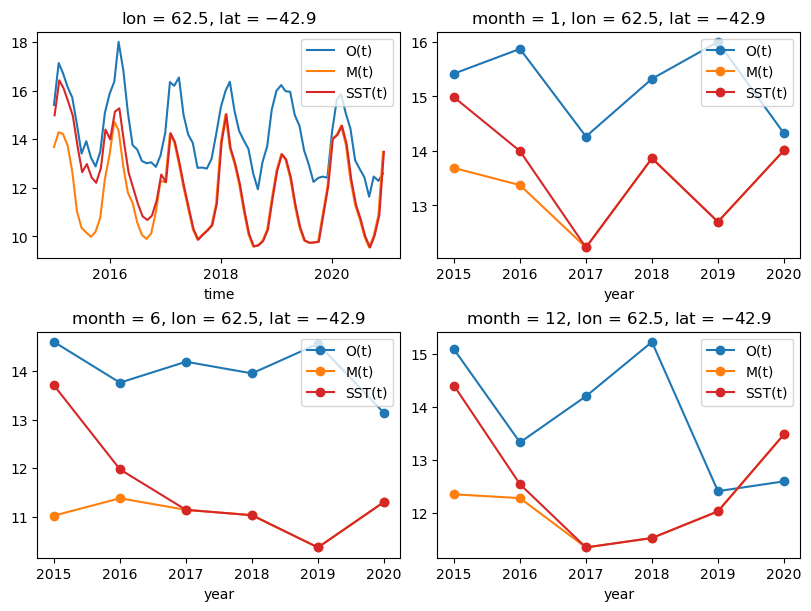

In [95]:
fig, ax = plot_single_gridcell(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_overlap_clim,
    obs_sst_overlap_my,
    lens_sst_overlap_my,
    sst_overlap_clim_my,
)

## using cosine smoothing without monthly climatology

In [96]:
relax_weights_time = cos_smooth_weights(relax_ntime + 1)
relax_param_time = build_relax_param_time(relax_weights_time, lens_sst_overlap)
sst_overlap_time = build_timeseries(lens_sst_overlap, obs_sst_overlap, relax_param_time).compute()
sst_overlap_time_my = split_years_months(sst_overlap_time).compute()

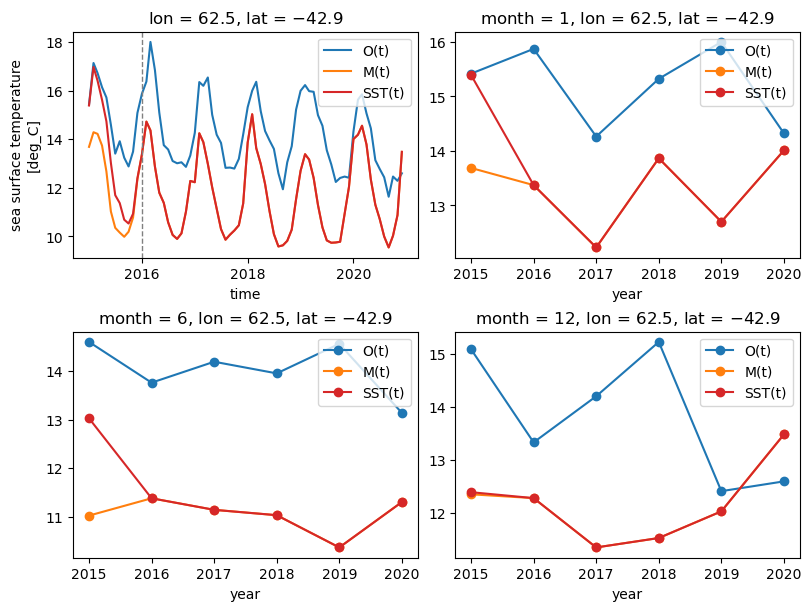

In [97]:
fig, ax = plot_single_gridcell(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_overlap_time,
    obs_sst_overlap_my,
    lens_sst_overlap_my,
    sst_overlap_time_my,
)
ax[0].axvline(cftime.DatetimeGregorian(2016, 1, 1), color='gray', lw=1, ls='--')

## compute for different relaxation window lengths

In [184]:
relax_nyear_list = np.arange(1, 4)
relax_ntime_list = 12 * relax_nyear_list

print(relax_nyear_list)

[1 2 3]


In [185]:
sst_relax = {}
sst_relax['clim'] = {'t': {}, 'my': {}}
sst_relax['time'] = {'t': {}, 'my': {}}

for i, (ny, nt) in enumerate(zip(relax_nyear_list, relax_ntime_list)):
    print(ny, end=' ')
    
    rw_clim = cos_smooth_weights(ny + 1)
    rp_clim_my = build_relax_param_clim(rw_clim, lens_sst_overlap_my)
    sst_clim_my = build_timeseries(lens_sst_overlap_my, obs_sst_overlap_my, rp_clim_my).compute()
    sst_clim = combine_years_months(sst_clim_my).compute()
    sst_relax['clim']['t'][str(ny)] = sst_clim
    sst_relax['clim']['my'][str(ny)] = sst_clim_my

    rw_time = cos_smooth_weights(nt + 1)
    rp_time = build_relax_param_time(rw_time, lens_sst_overlap)
    sst_time = build_timeseries(lens_sst_overlap, obs_sst_overlap, rp_time).compute()
    sst_time_my = split_years_months(sst_time).compute()
    sst_relax['time']['t'][str(ny)] = sst_time
    sst_relax['time']['my'][str(ny)] = sst_time_my

1 2 3 

In [12]:
t = slice("1990-01", "2014-12")

In [13]:
t.stop

'2014-12'

## regional plots

In [186]:
sst_region_bnds = {
    'glb': [[-90, 90], [0, 360]],
    'nat': [[47, 57], [315, 335]],
    'npa': [[30, 50], [150, 230]],
    'nep': [[35, 50], [190, 220]],
    'sep': [[-62, -47], [220, 290]],
    'ind': [[-15, 5], [60, 90]],
    'sop': [[-62, -47], [100, 140]],
    'so': [[-90, -50], [0, 360]],
}

sst_region_names = {
    'glb': 'Global',
    'nat': 'N. Atlantic box',
    'npa': 'N. Pacific box',
    'nep': 'N. East Pacific box',
    'sep': 'S. East Pacific box',
    'ind': 'Indian Ocean box',
    'sop': 'Southern Ocean box',
    'so': 'Southern Ocean',
}

sst_regions = {}
for name, bnds in sst_region_bnds.items():
    lat_bnds = bnds[0]
    lon_bnds = bnds[1]
    reg = ((area.lat >= lat_bnds[0]) & (area.lat < lat_bnds[1]) & (area.lon >= lon_bnds[0]) & (area.lon < lon_bnds[1]))
    sst_regions[name] = reg.where(om).rename(name)

In [187]:
end_time = '2016-01'
use_cftime = True

def plot_nregions(obs, lens, sst, regions, region_names, end_time, label, use_cftime=True, **kwargs):

    if use_cftime:
        time_slice = {'time': slice(None, end_time)}
    else:
        time_slice = {'year': slice(None, end_time)}

    ncol = len(regions.keys())
    fig, ax = plt.subplots(3, ncol, figsize=(3*ncol, 5), layout='constrained', sharex=True, dpi=150)

    for i, (name, reg) in enumerate(regions.items()):
        obs_reg = obs.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()
        lens_reg = lens.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()
        
        for j, (ny, da) in enumerate(sst.items()):
            sst_reg = da.sel(**time_slice).where(reg).weighted(oa).mean(dim=['lat', 'lon']).compute()

            obs_reg.plot(ax=ax[j, i], c='tab:blue', ls='-', label='O(t)', **kwargs)
            lens_reg.plot(ax=ax[j, i], c='tab:orange', ls='-', label='M(t)', **kwargs)
            sst_reg.plot(ax=ax[j, i], c='tab:red', ls='-', label='SST(t)', **kwargs)

            ax[j, i].set_ylabel('')
            ax[j, i].set_xlabel('')
            ax[j, i].set_title('')
        
        ax[0, i].set_title(region_names[name])
        
    ax[0, -1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

    for j, ny in enumerate(sst.keys()):
        ax[j, 0].set_ylabel(f'relax_nyear = {ny}')
    
    fig.suptitle(label, fontweight='bold')
    return fig, ax

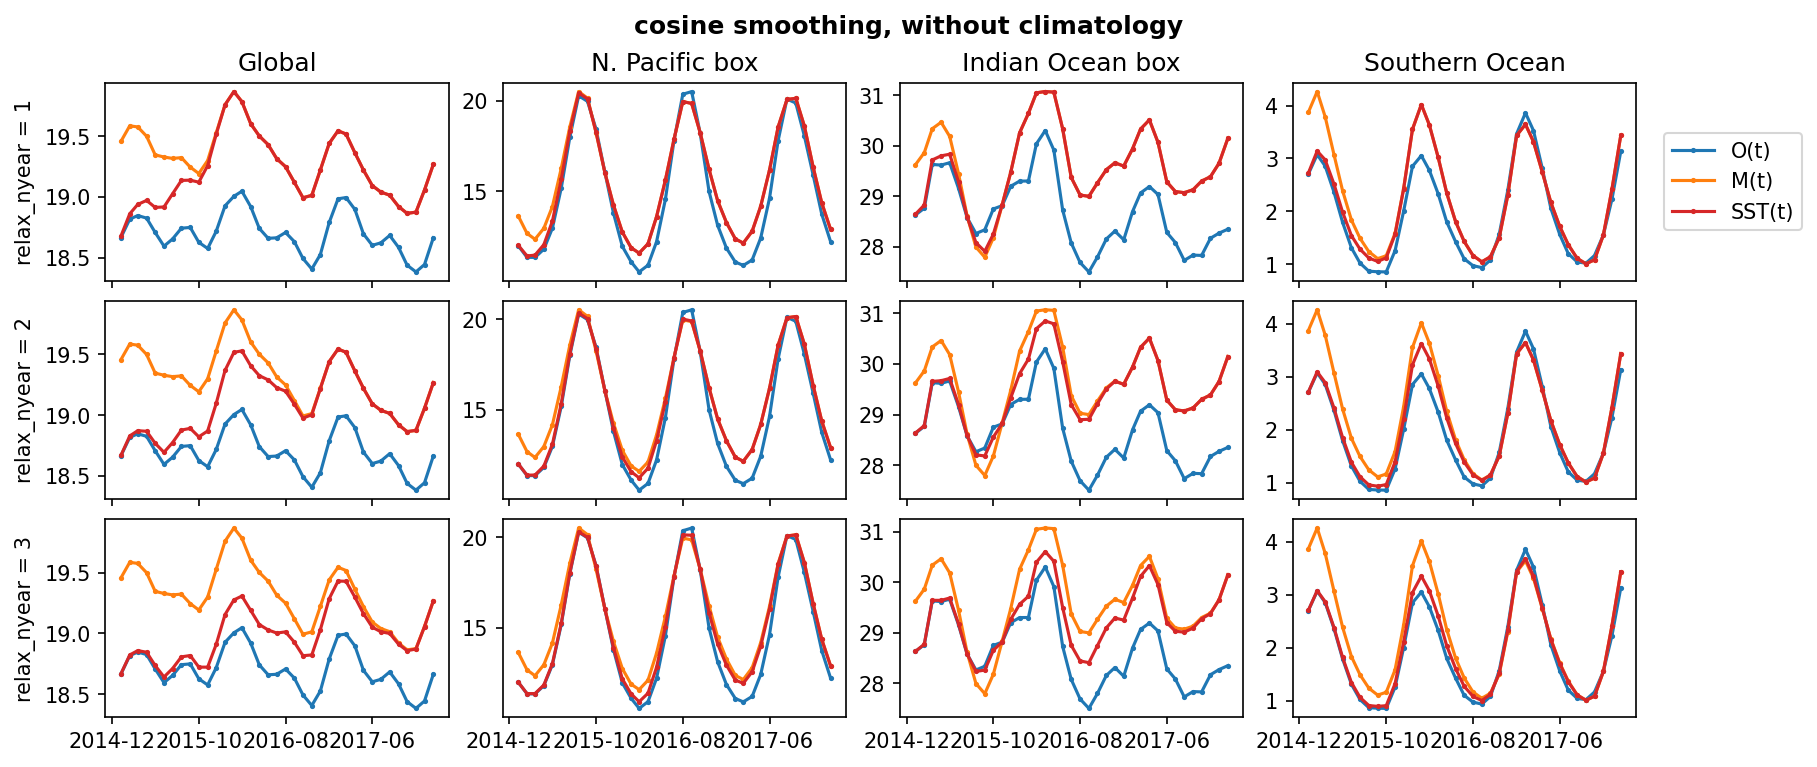

In [166]:
keep = ["glb", "npa", "ind", "so"]
sst_regions_sub = {k: sst_regions[k] for k in keep}
sst_region_names_sub = {k: sst_region_names[k] for k in keep}

plot_nregions(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_relax['time']['t'],
    sst_regions_sub,
    sst_region_names_sub,
    end_time='2018-01',
    label='cosine smoothing, without climatology',
    use_cftime=True,
    marker='o', markersize=1.5,
);

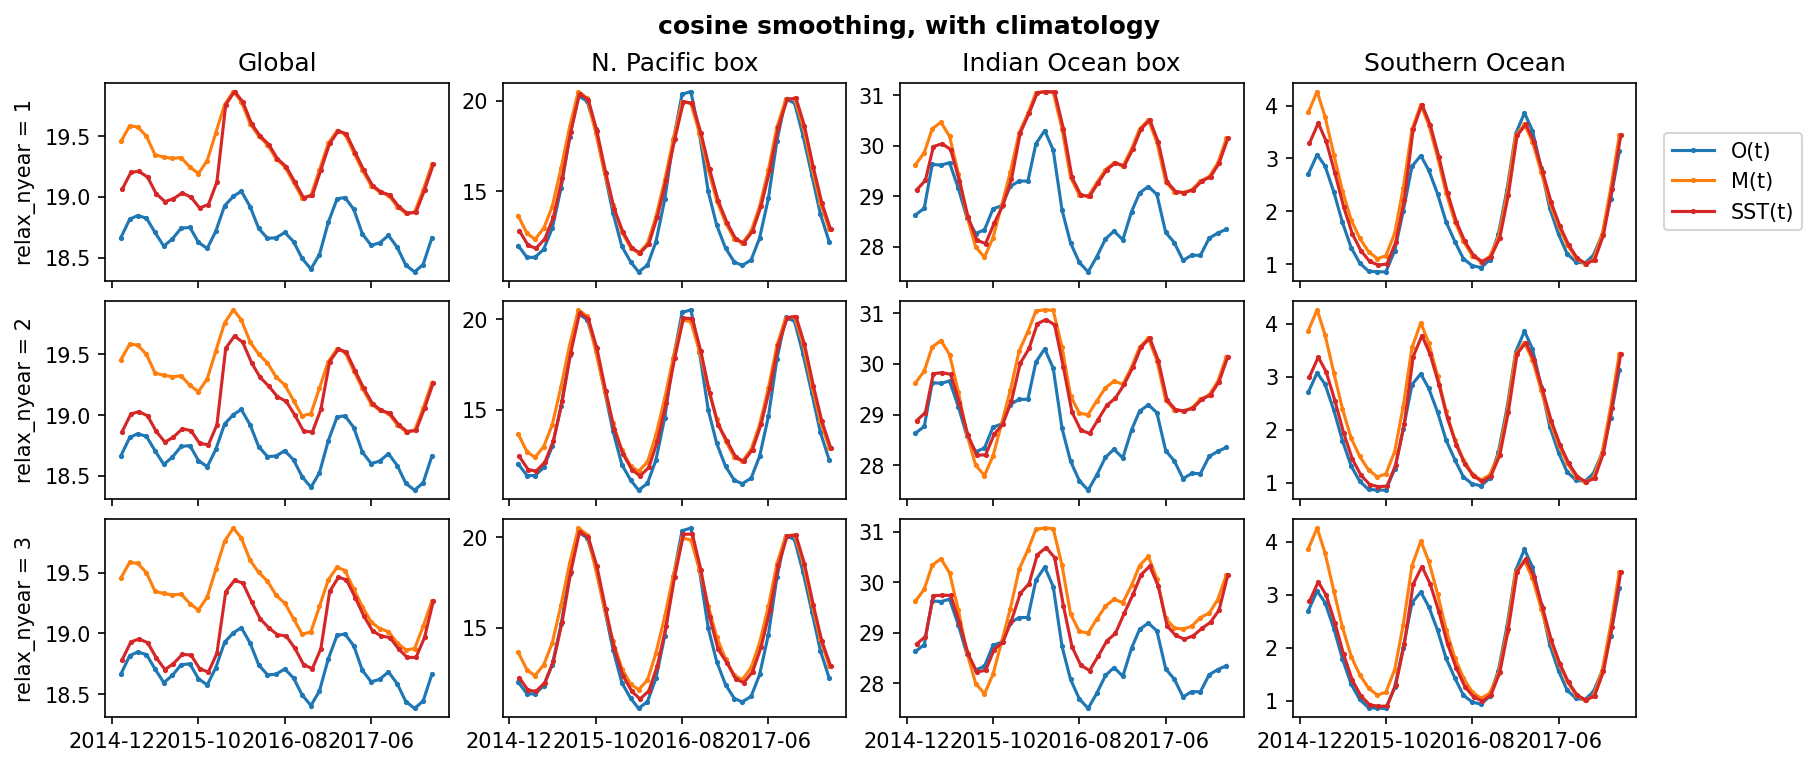

In [219]:
keep = ["glb", "npa", "ind", "so"]
sst_regions_sub = {k: sst_regions[k] for k in keep}
sst_region_names_sub = {k: sst_region_names[k] for k in keep}

plot_nregions(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_relax['clim']['t'],
    sst_regions_sub,
    sst_region_names_sub,
    end_time='2018-01',
    label='cosine smoothing, with climatology',
    use_cftime=True,
    marker='o', markersize=1.5,
);

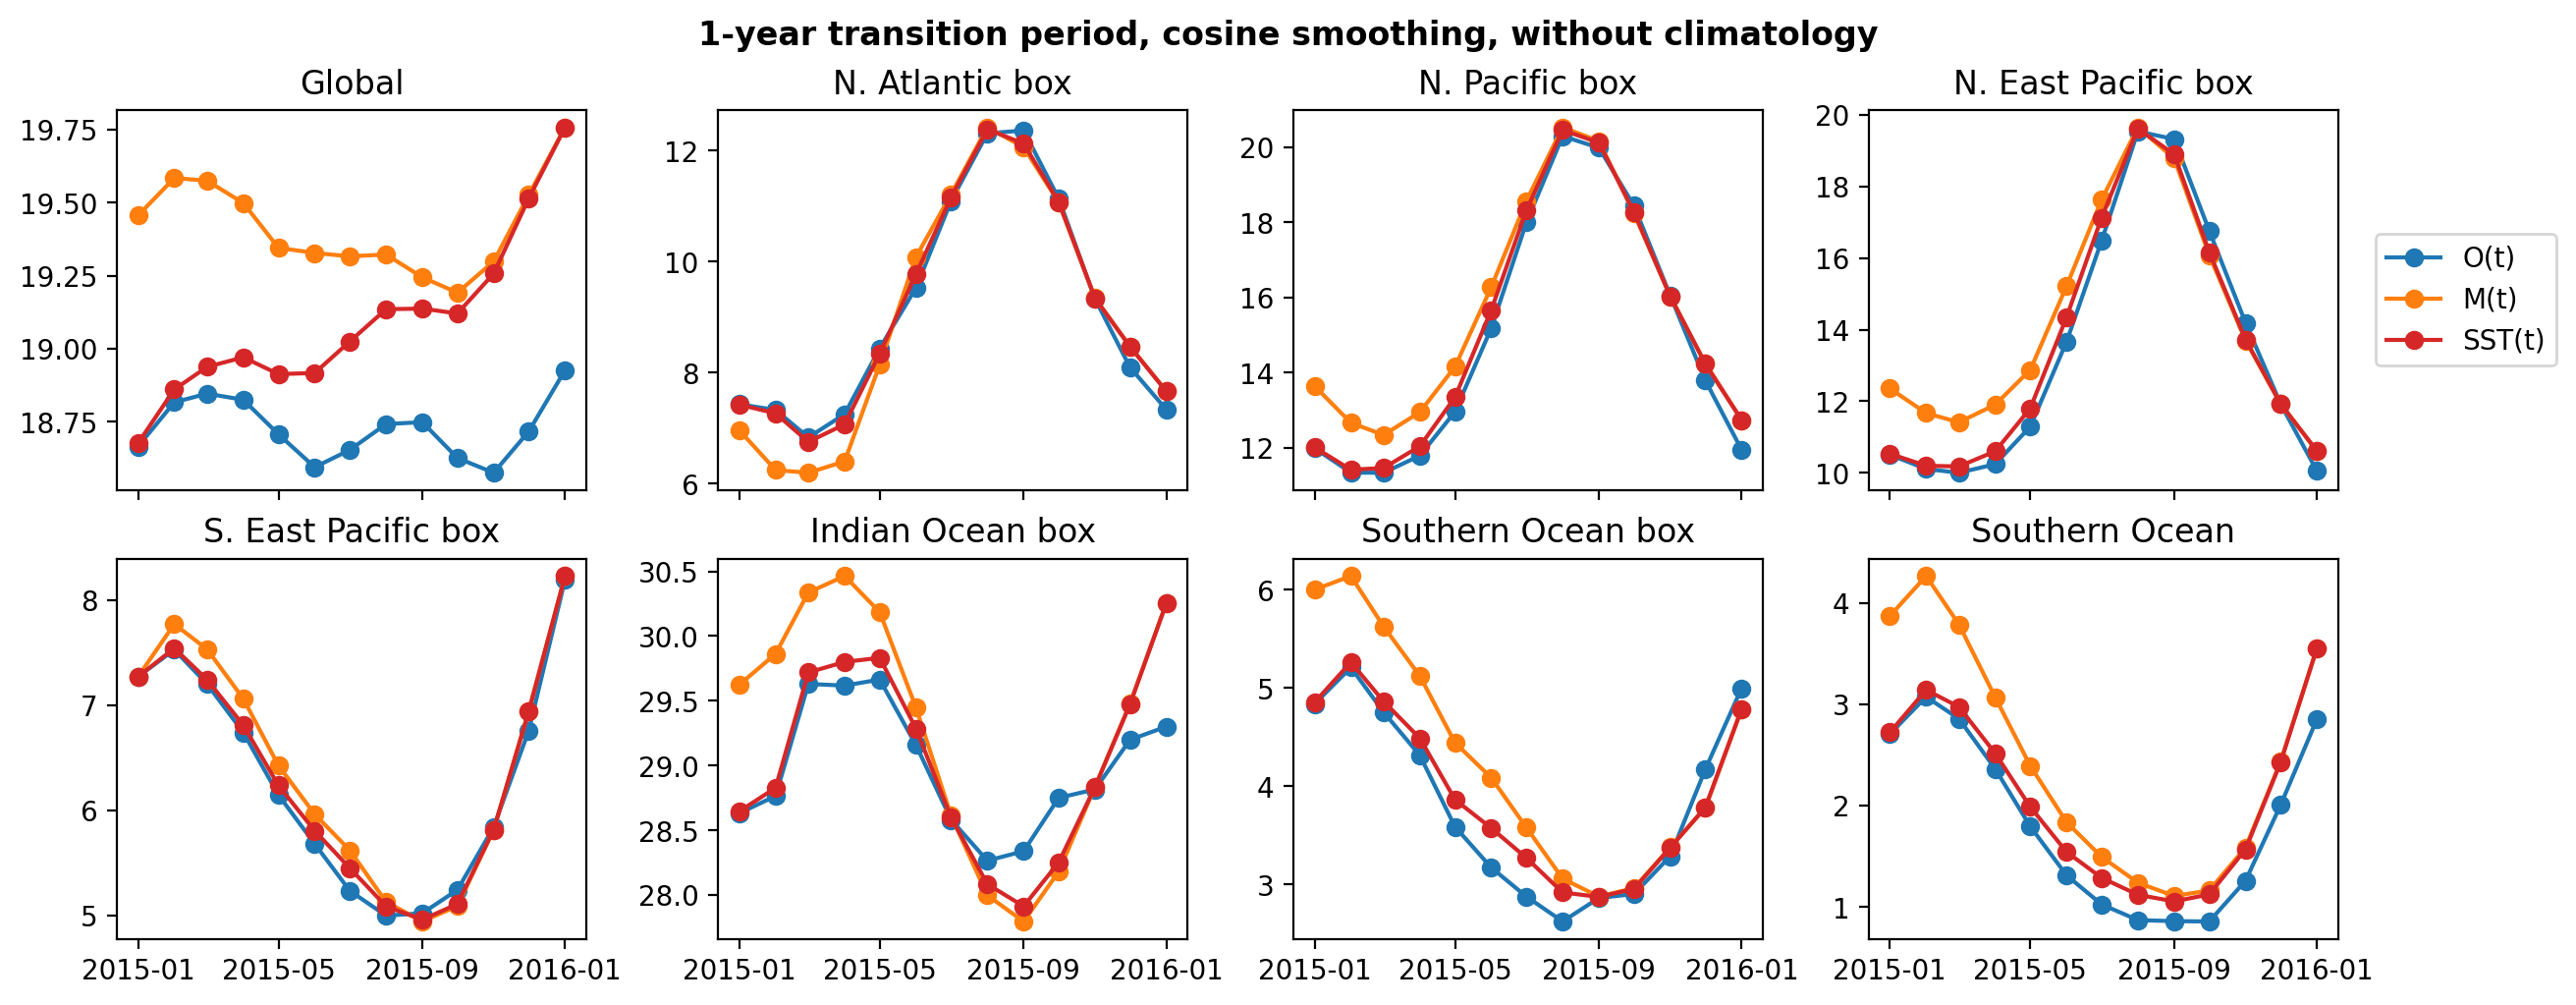

In [118]:
fig, ax = plot_regions(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_relax['time']['1']['t'],
    sst_regions,
    sst_region_names,
    end_time='2016-01',
    label='1-year transition period, cosine smoothing, without climatology',
    marker='o'
)

Text(0.5, 1.025, '1-year transition period, cosine smoothing, without climatology')

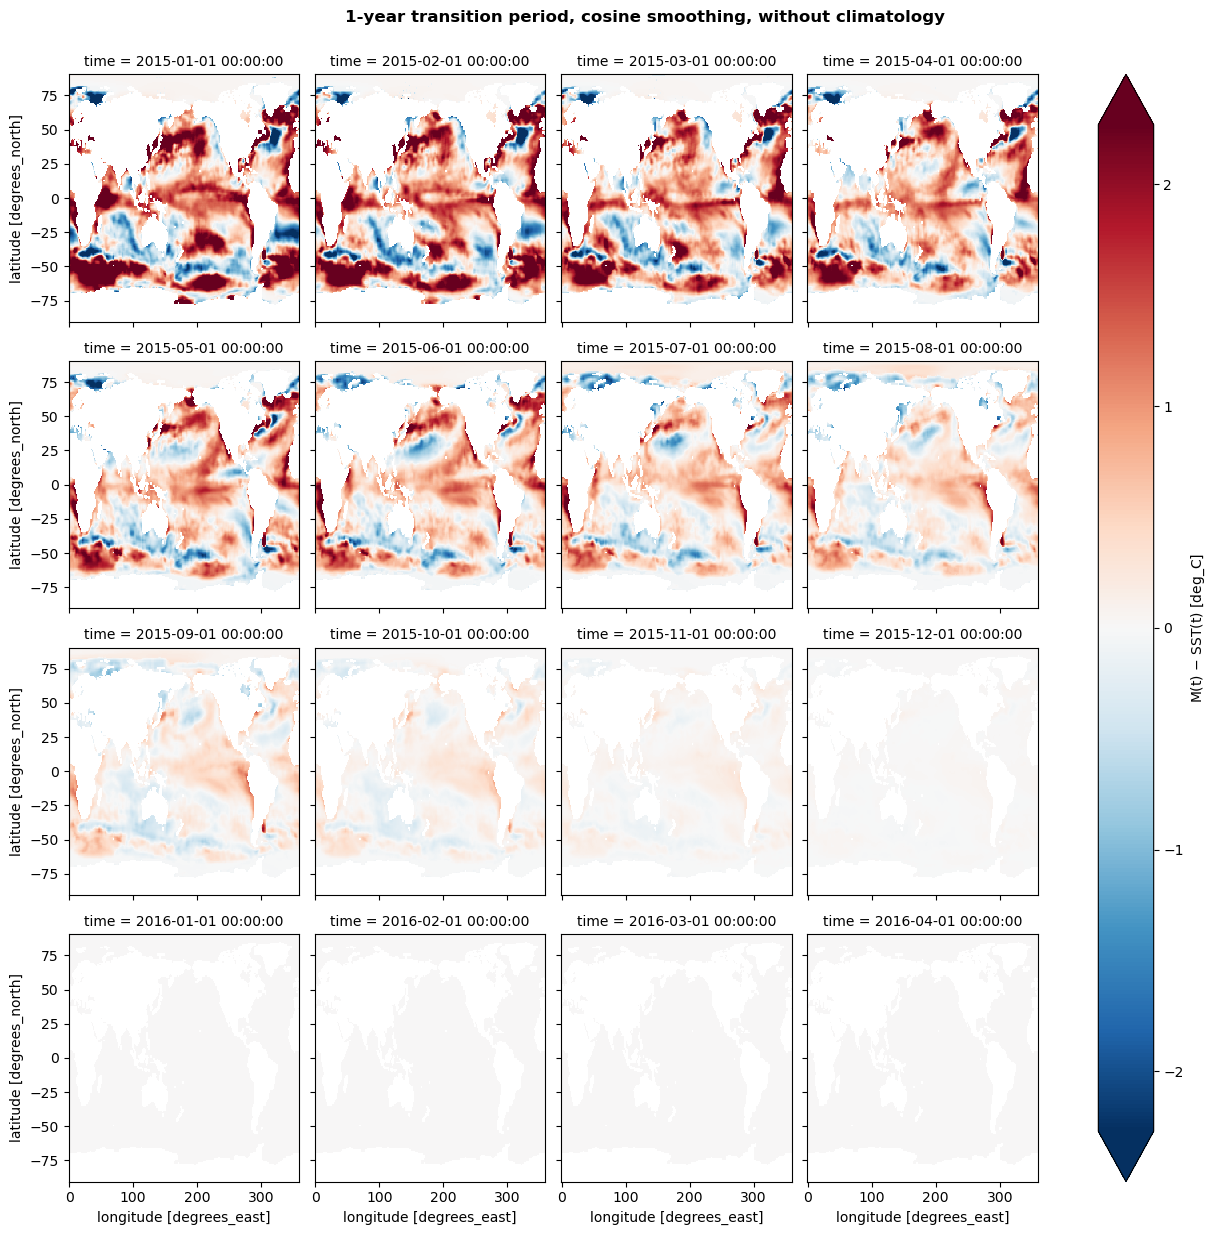

In [228]:
fg = (lens_sst_overlap - sst_relax['time']['t']['1']).sel(time=slice(None, '2016-04')).plot(col='time', col_wrap=4, robust=True, cbar_kwargs={'label': 'M(t) $-$ SST(t) [deg_C]'})
fg.fig.suptitle('1-year transition period, cosine smoothing, without climatology', fontweight='bold', y=1.025)

Text(0.5, 1.025, '1-year transition period, cosine smoothing, with climatology')

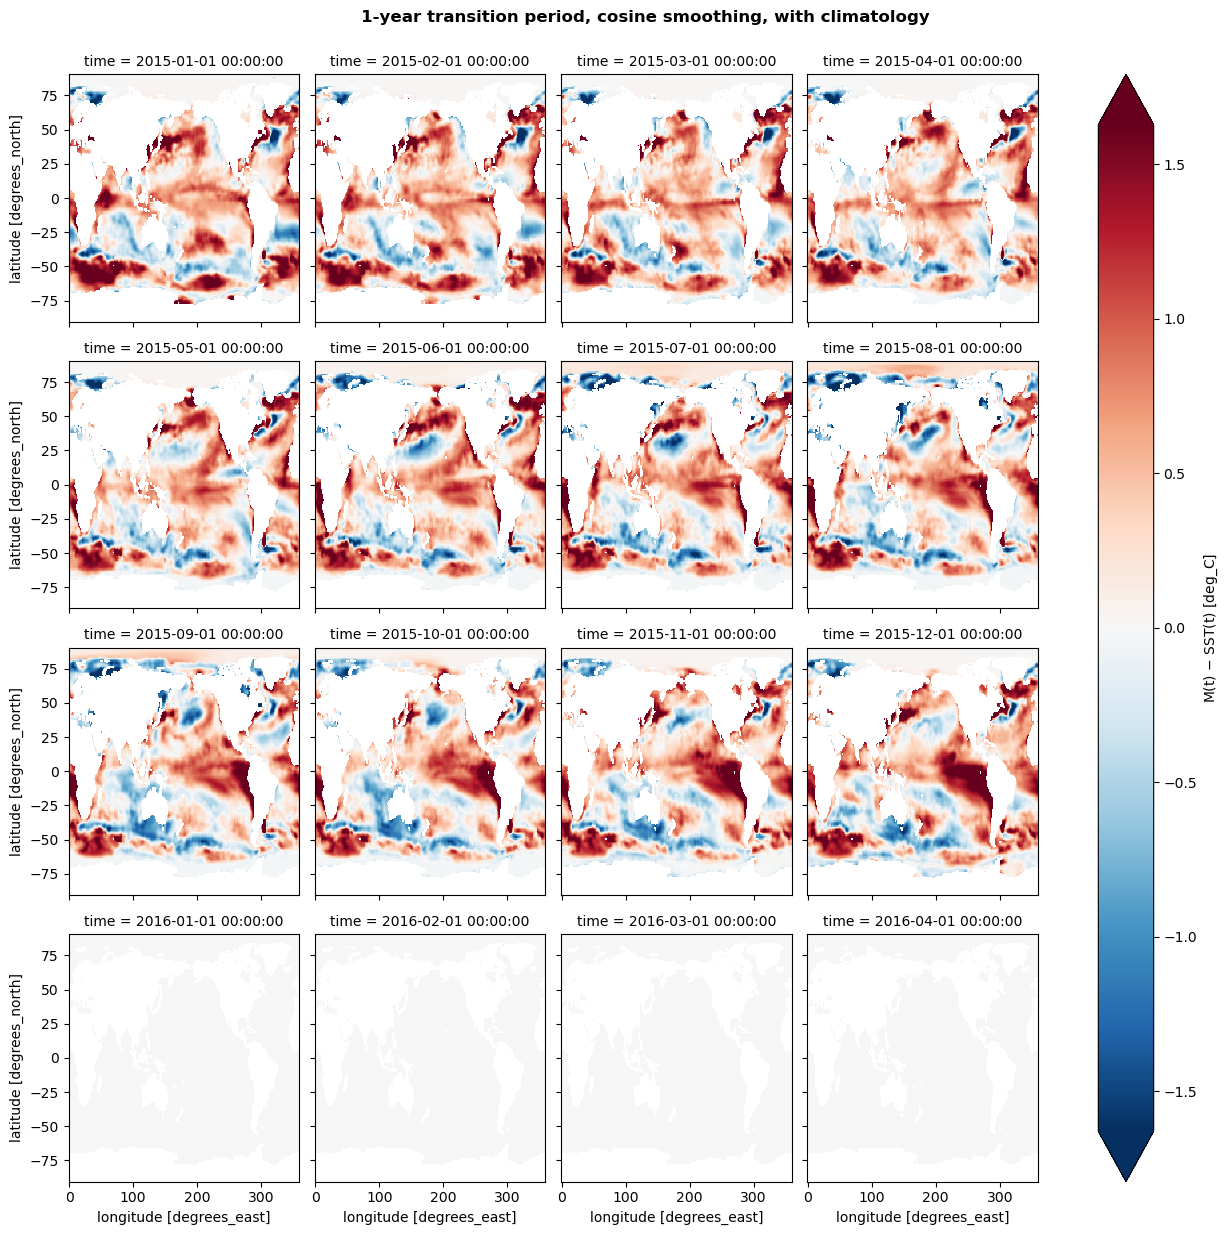

In [227]:
fg = (lens_sst_overlap - sst_relax['clim']['t']['1'].assign_coords(time=lens_sst_overlap.time)).sel(time=slice(None, '2016-04')).plot(col='time', col_wrap=4, robust=True, cbar_kwargs={'label': 'M(t) $-$ SST(t) [deg_C]'})
fg.fig.suptitle('1-year transition period, cosine smoothing, with climatology', fontweight='bold', y=1.025)

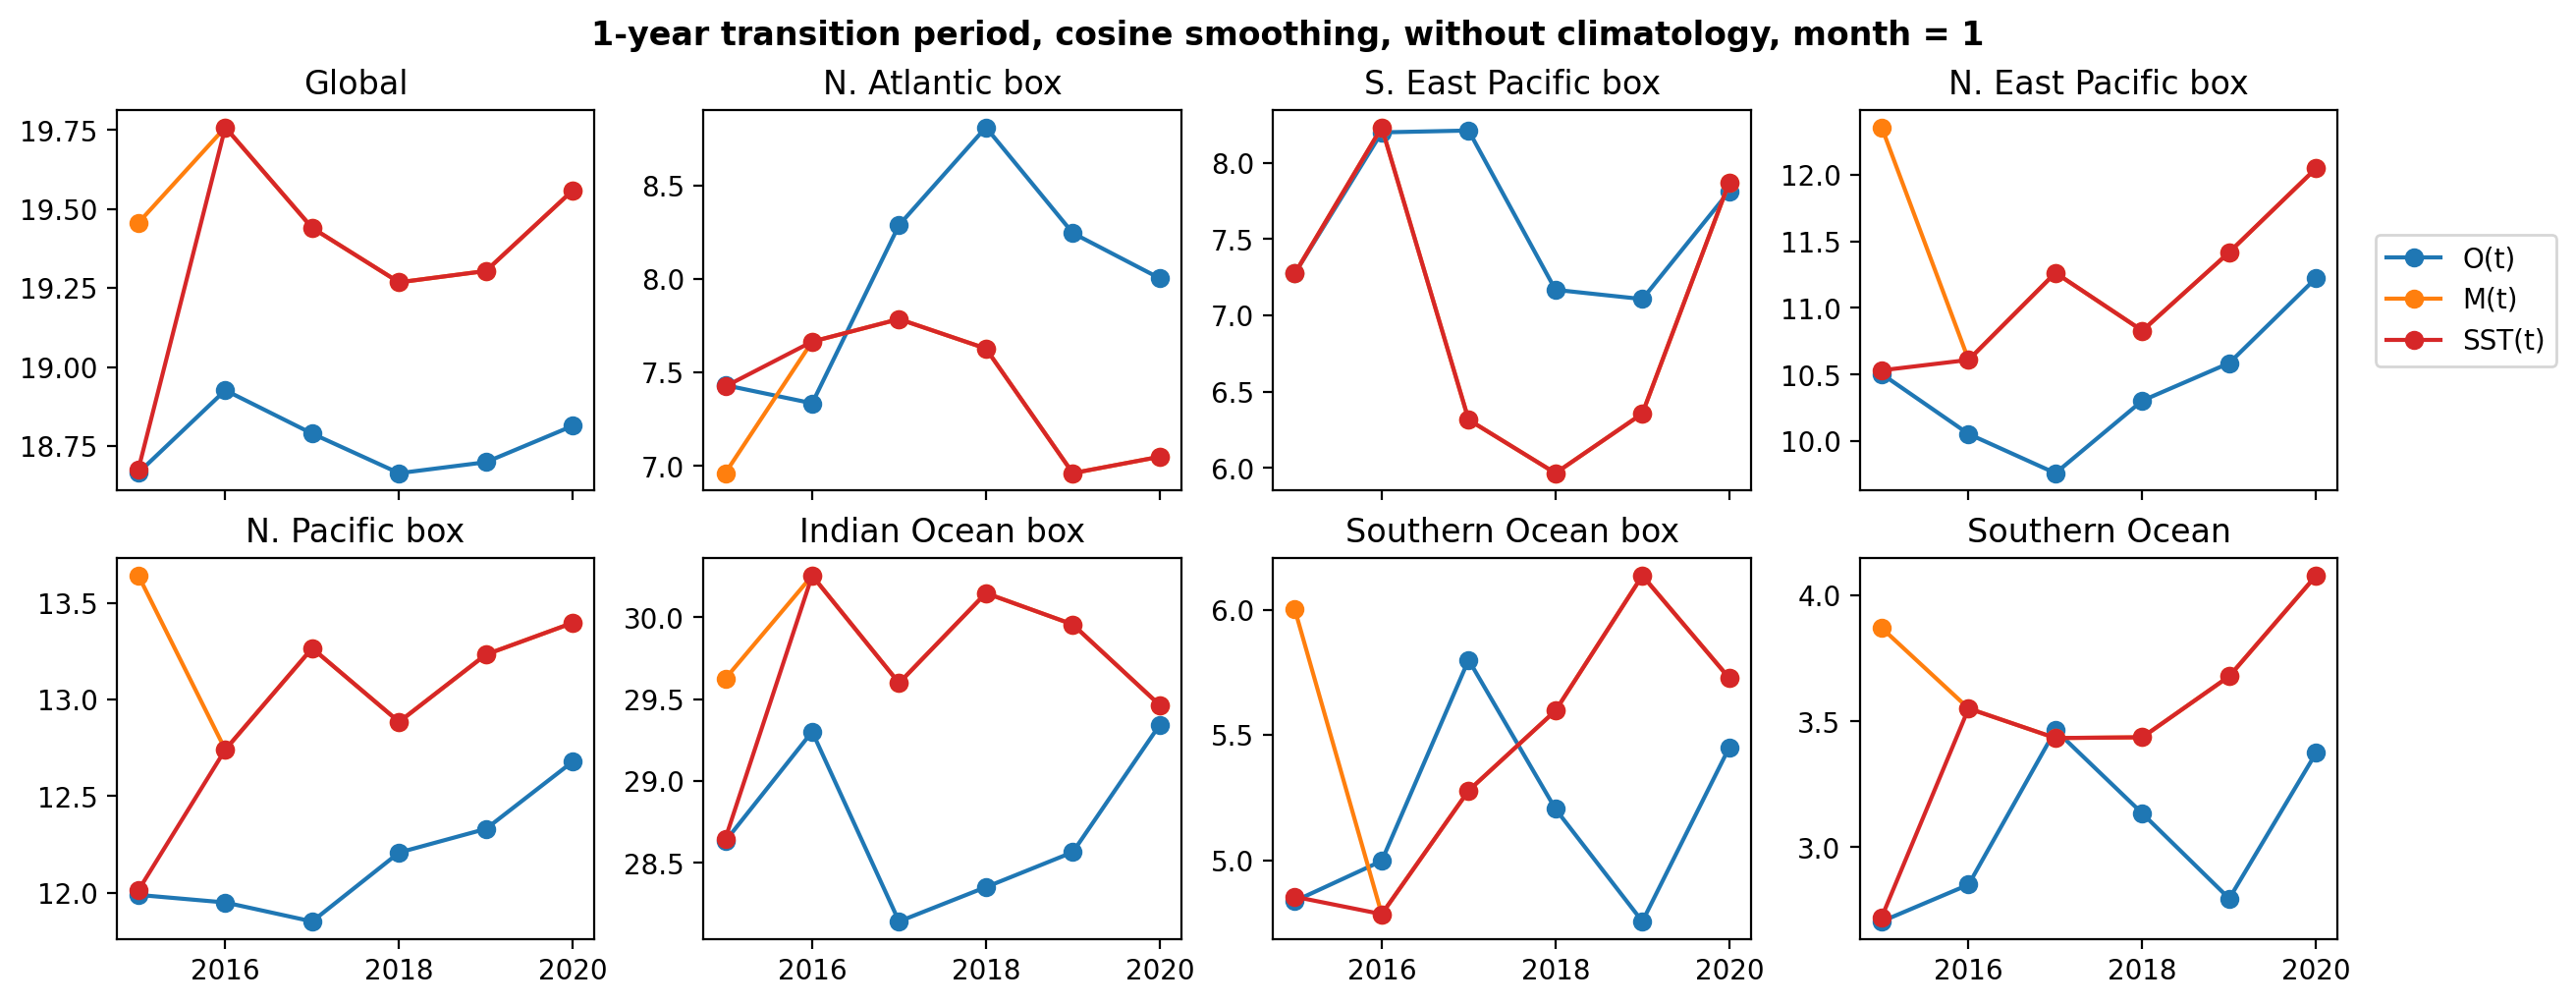

In [ ]:
month = 1
fig, ax = plot_regions(
    obs_sst_overlap.where(obs_sst_overlap.time.dt.month == month, drop=True),
    lens_sst_overlap.where(lens_sst_overlap.time.dt.month == month, drop=True),
    sst_relax['time']['t']['1'].where(sst_relax['time']['t']['1'].time.dt.month == month, drop=True),
    sst_regions,
    sst_region_names,
    end_time='2020',
    label=f'1-year transition period, cosine smoothing, without climatology, month = {month}',
    use_cftime=True,
    marker='o'
)

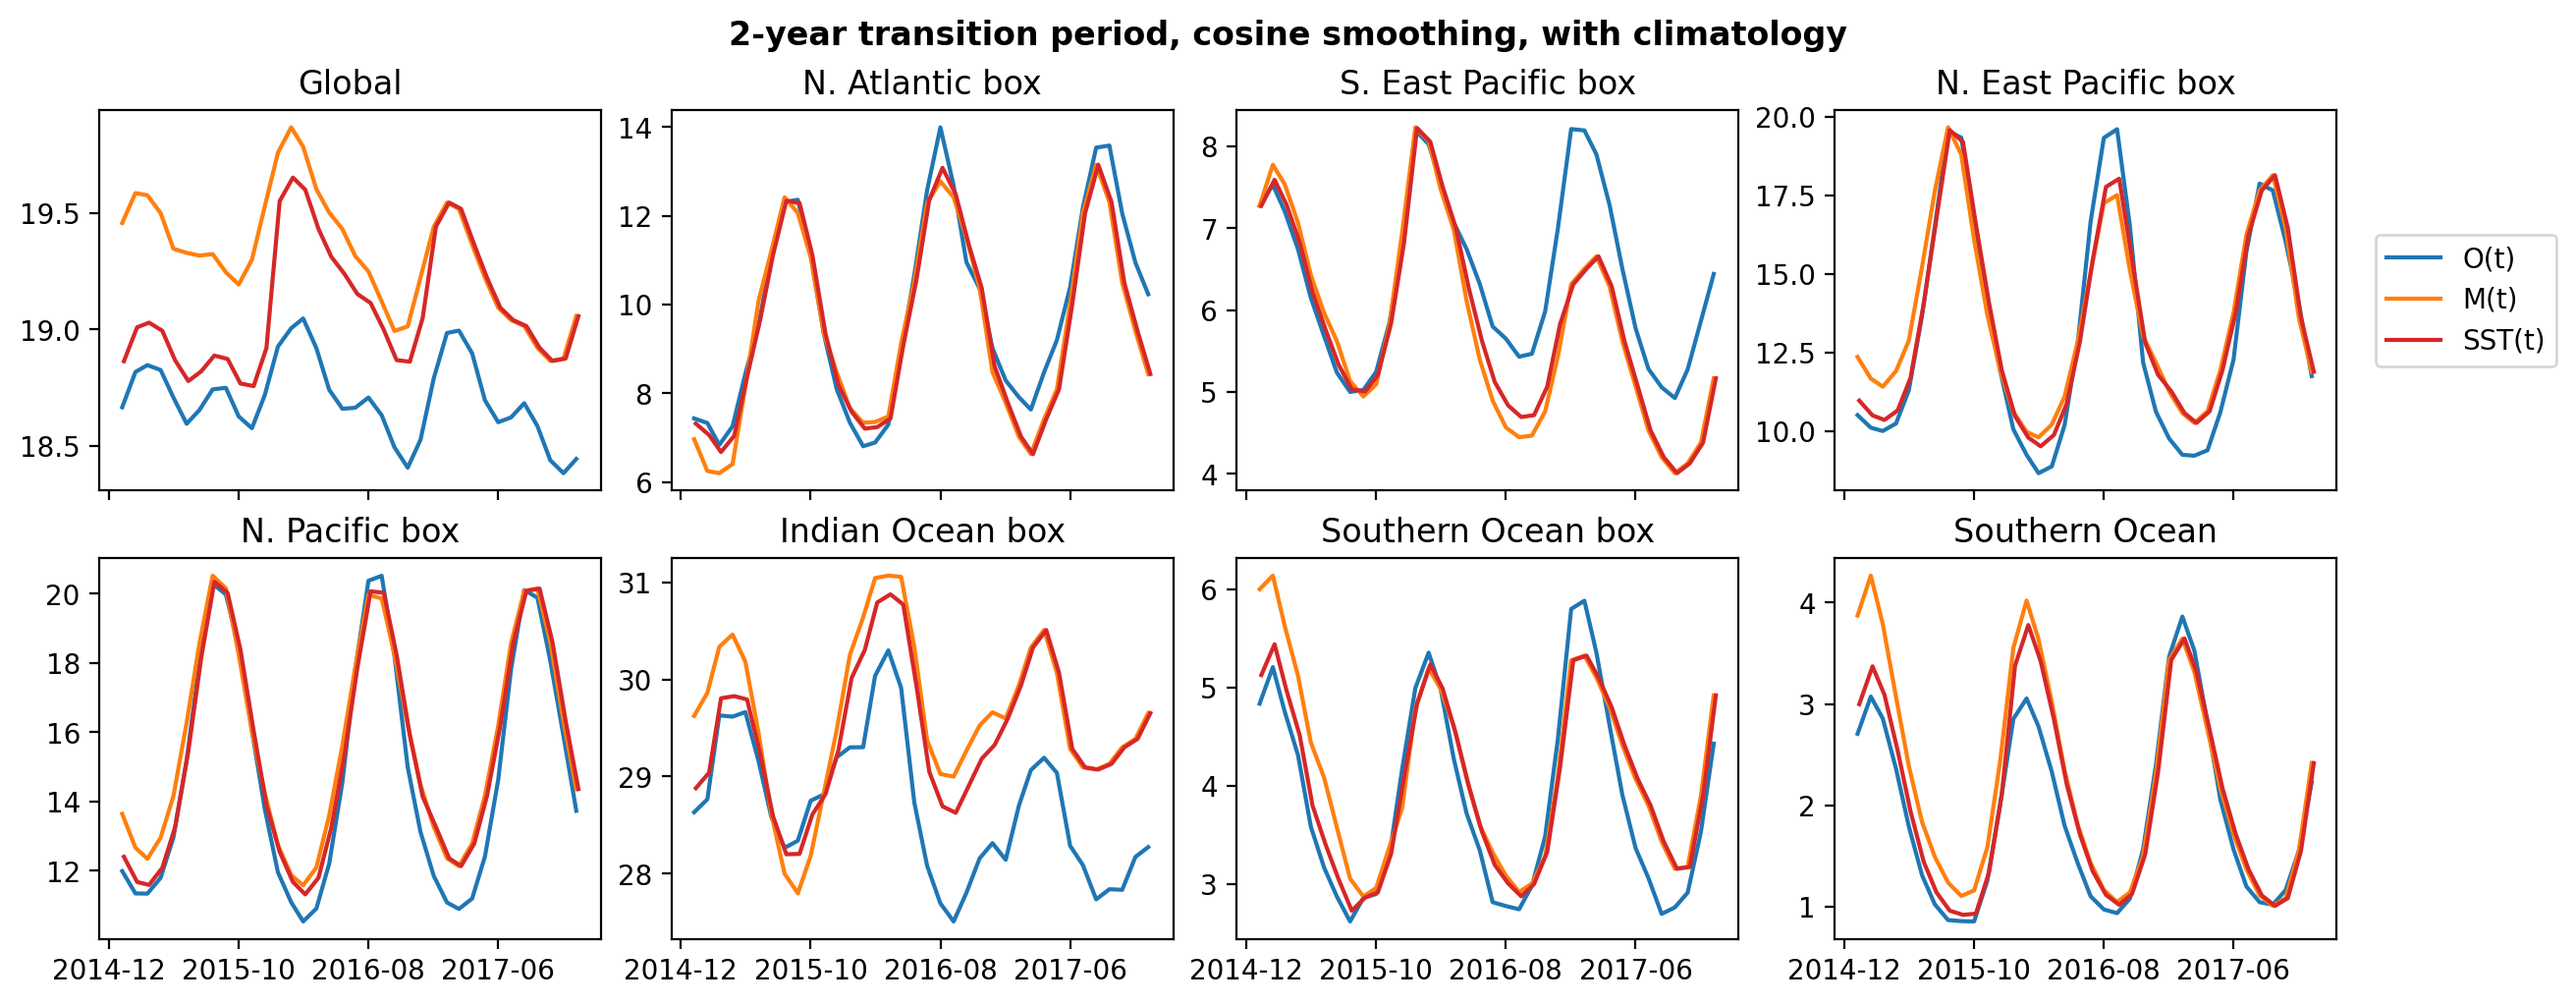

In [ ]:
fig, ax = plot_regions(
    obs_sst_overlap,
    lens_sst_overlap,
    sst_relax['clim']['t']['2'],
    sst_regions,
    sst_region_names,
    end_time='2017-12',
    label='2-year transition period, cosine smoothing, with climatology'
)

<Figure size 320x240 with 0 Axes>

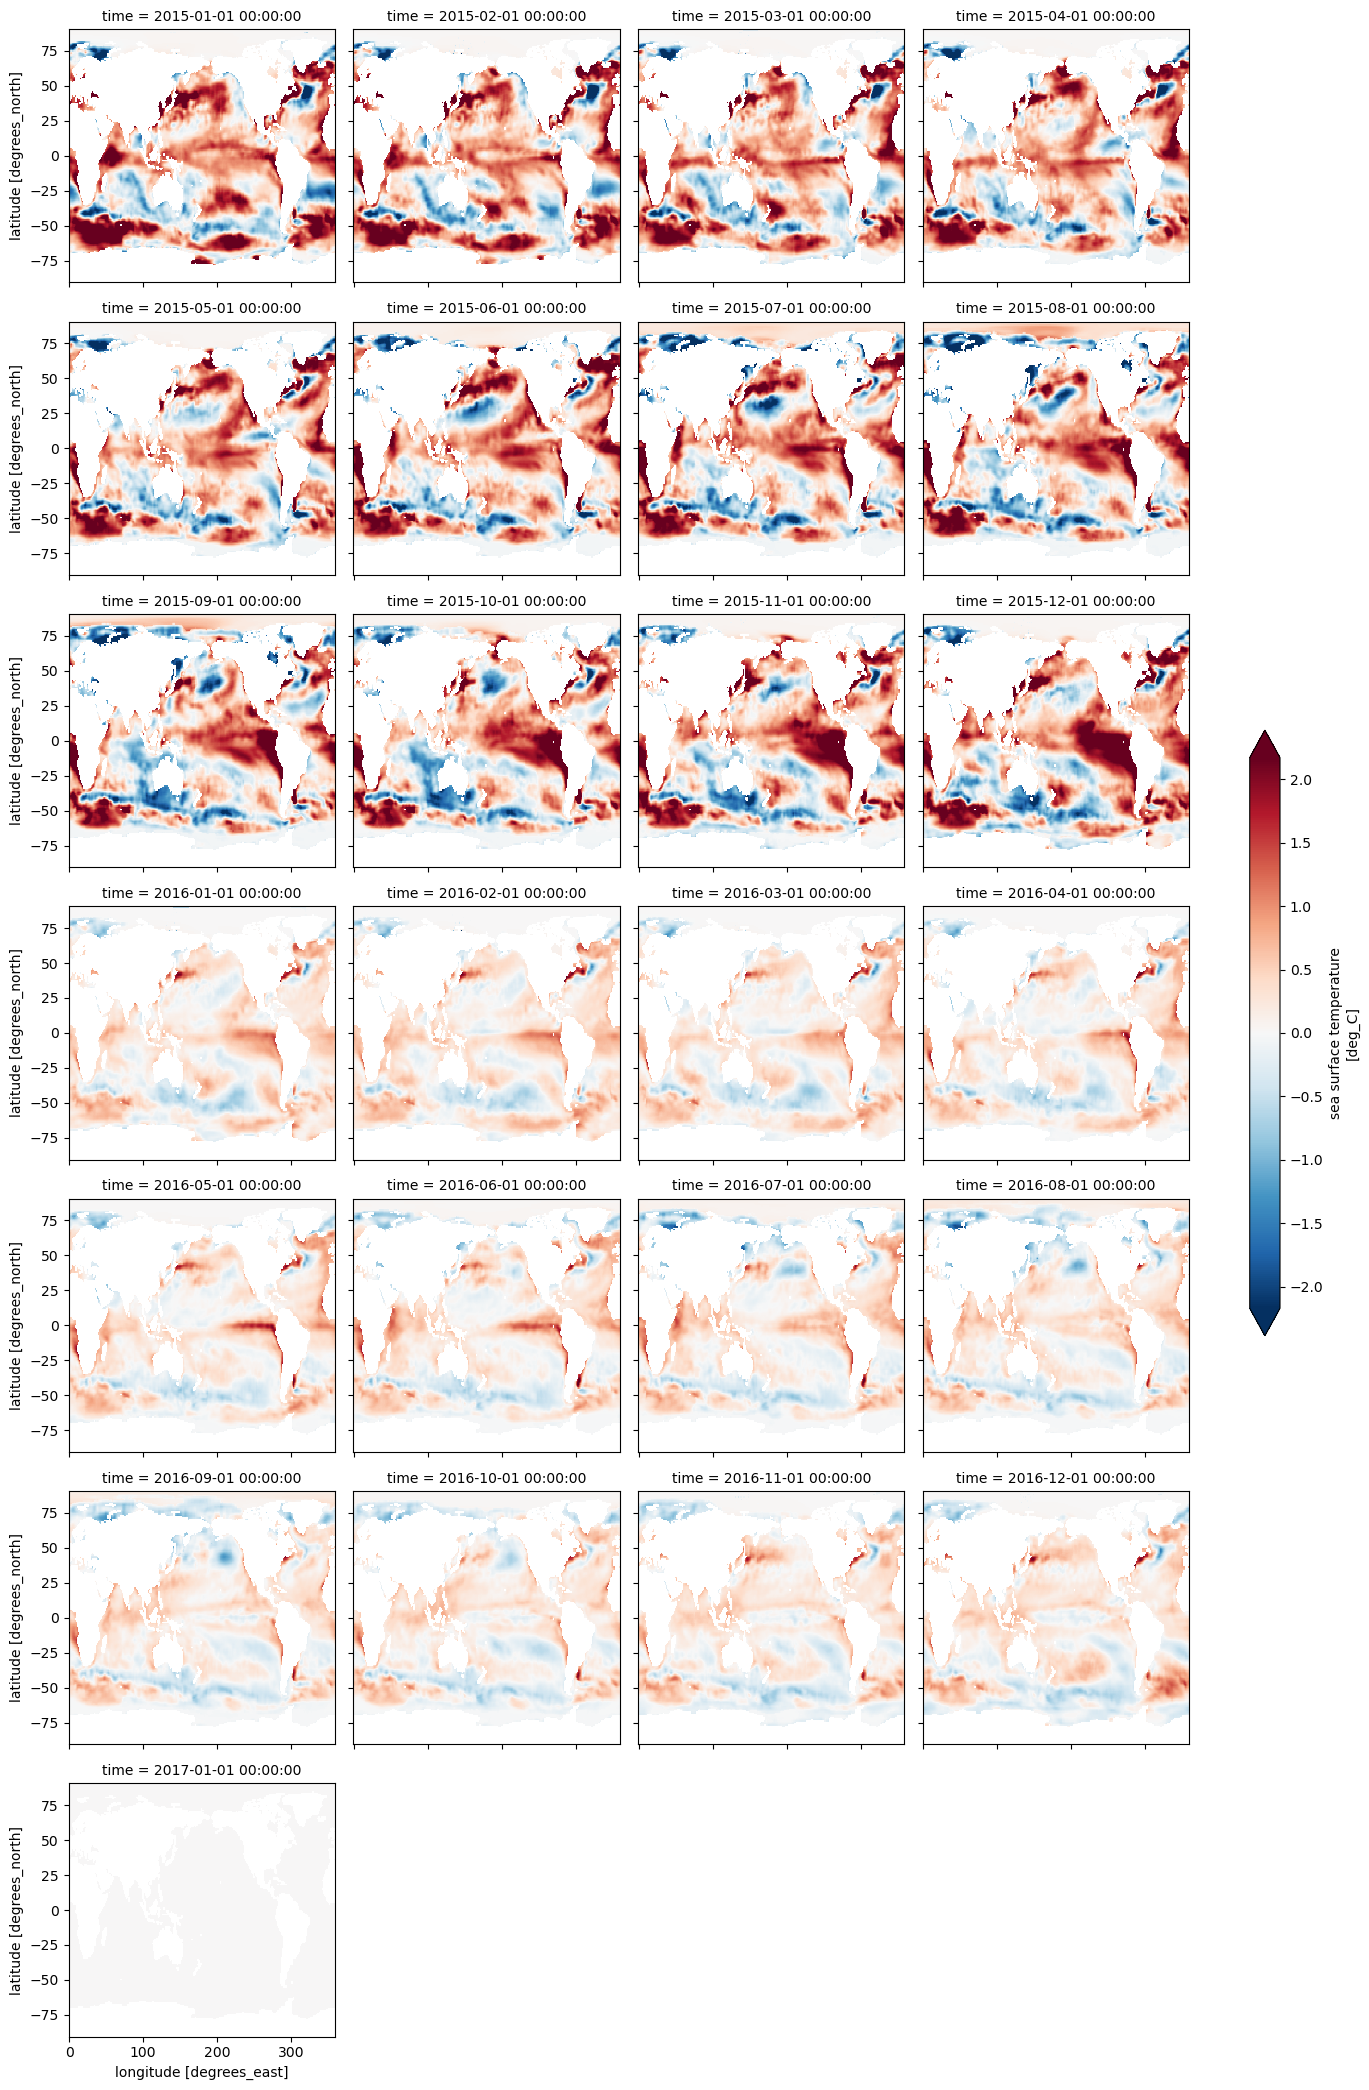

In [167]:
plt.figure(dpi=50)
(lens_sst_overlap - sst_relax['clim']['t']['2'].assign_coords(time=lens_sst_overlap.time)).sel(time=slice(None, '2017-01')).plot(col='time', col_wrap=4, robust=True, cbar_kwargs={'fraction': 0.025})

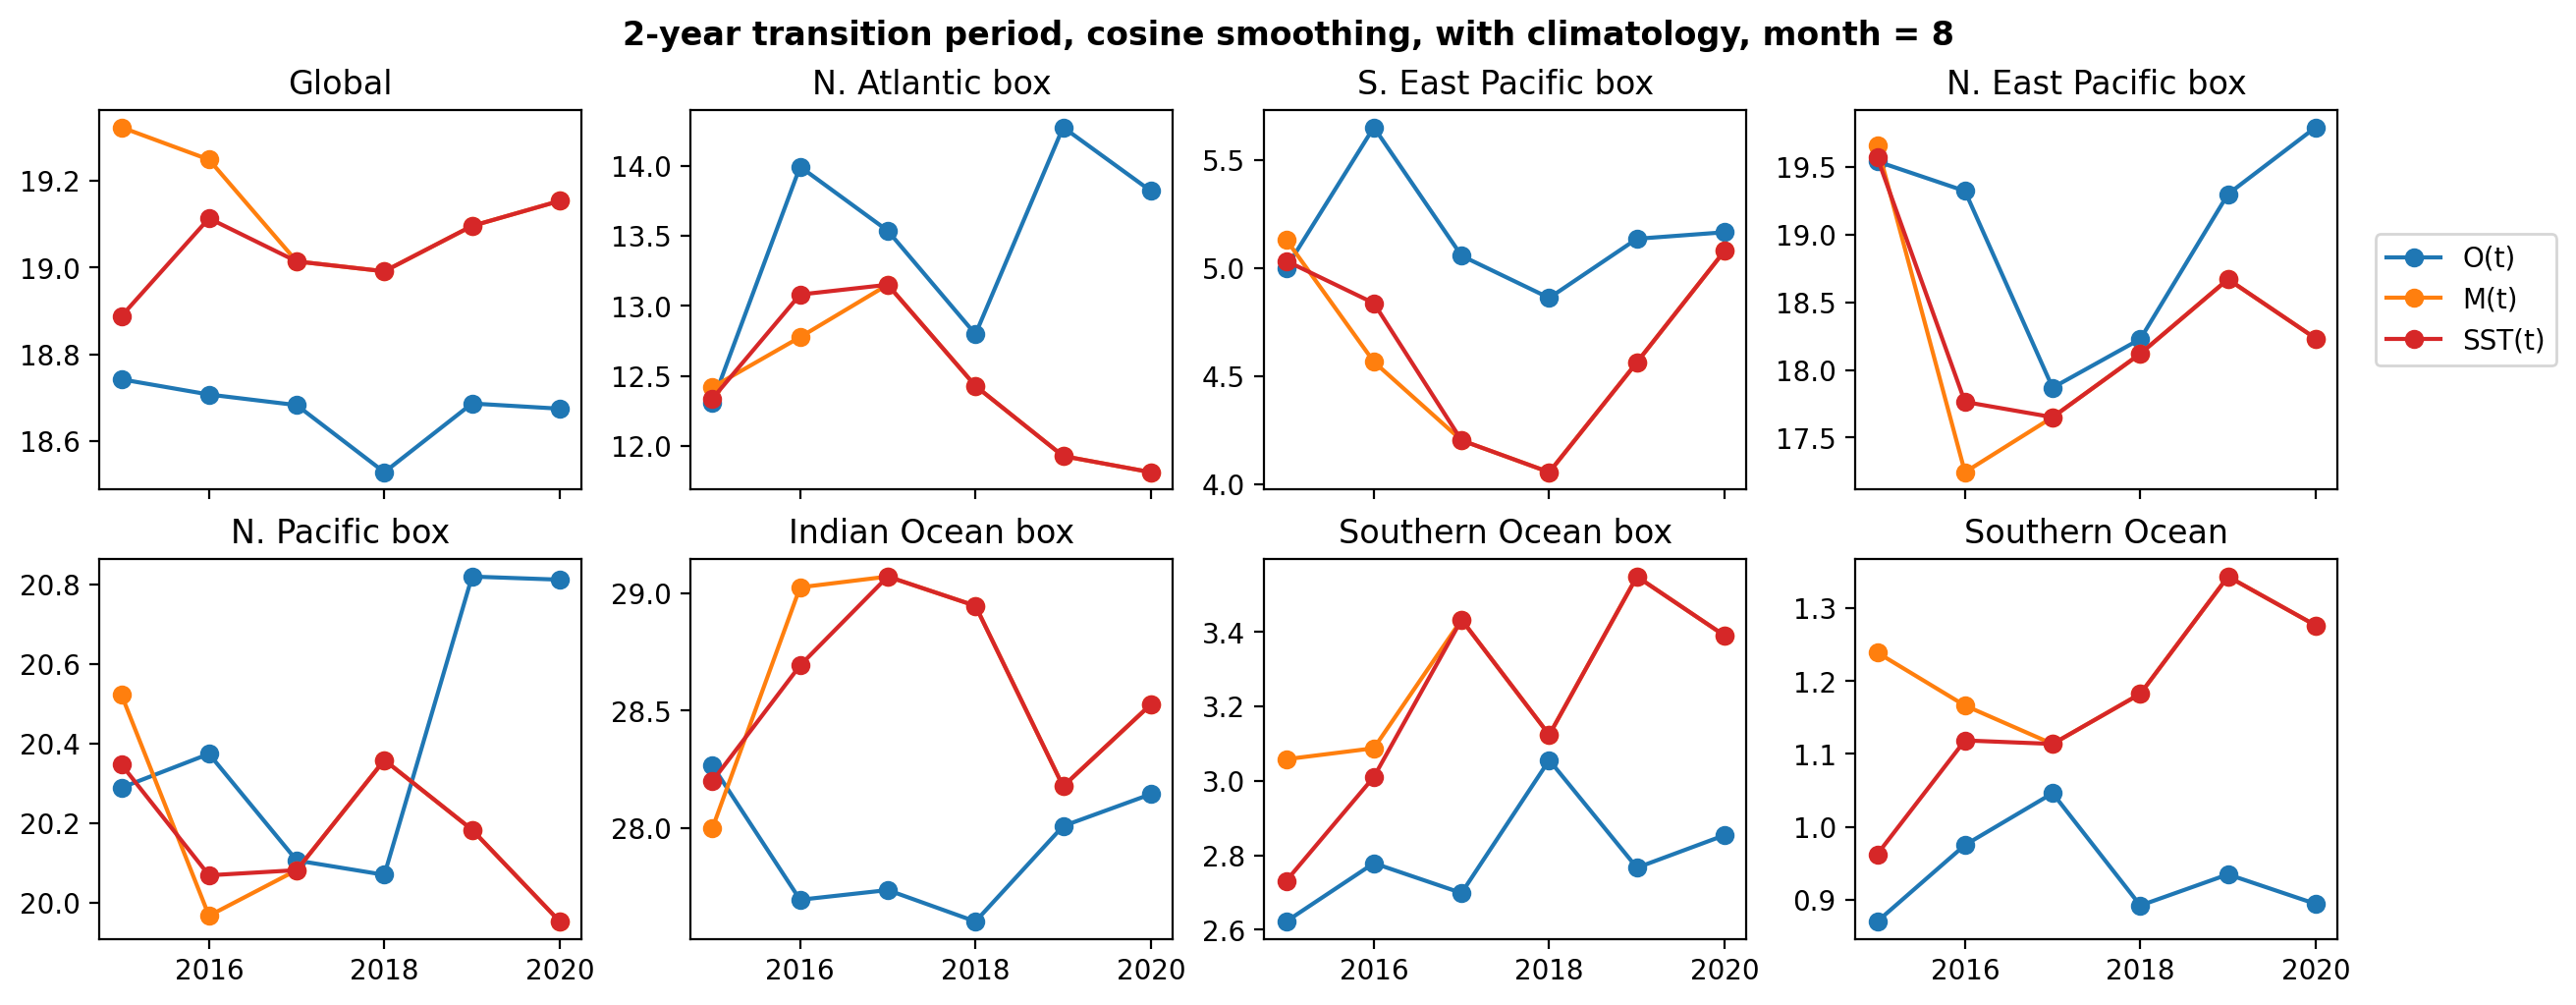

In [ ]:
month = 8
fig, ax = plot_regions(
    obs_sst_overlap_my.sel(month=month),
    lens_sst_overlap_my.sel(month=month),
    sst_relax['clim']['my']['2'].sel(month=month),
    sst_regions,
    sst_region_names,
    end_time=2020,
    label=f'2-year transition period, cosine smoothing, with climatology, month = {month}',
    use_cftime=False,
    marker='o'
)

## compute NINO3.4

In [ ]:
def compute_nino34_rolling_reference(sst, area, rolling_nmonths=5):
    '''
    "Nino X Index computation: (a) Compute area averaged total SST from Niño X region; (b) Compute monthly climatology
    (e.g., 1950-1979) for area averaged total SST from Niño X region, and subtract climatology from area averaged total
    SST time series to obtain anomalies; (c) Smooth the anomalies with a 5-month running mean; (d) Normalize the smoothed
    values by its standard deviation over the climatological period."
    https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni#:~:text=Technical%20Notes
    '''
    sst_nino34 = sst.sel(lat=slice(-5, 5), lon=slice(190, 240))
    sst_nino34_ts = sst_nino34.weighted(area).mean(dim=['lat', 'lon'])

    sst_nino34_base_mean = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).mean().ffill('time').bfill('time'))
    )
    sst_nino34_base_std = (
        sst_nino34_ts
        .groupby('time.month')
        .map(lambda x: x.rolling(time=30, center=True).std().ffill('time').bfill('time'))
    )

    sst_nino34_anom_mean_norm = (sst_nino34_ts - sst_nino34_base_mean) / sst_nino34_base_std

    nino34 = sst_nino34_anom_mean_norm.rolling(time=rolling_nmonths, center=True).mean()

    return nino34


def plot_nino34(nino34):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 >= 0.5).data,
        0.5,
        color = "red",
        alpha = 0.9,
    )
    ax.fill_between(
        nino34.time.data,
        nino34.where(nino34 <= -0.5).data,
        -0.5,
        color = "blue",
        alpha = 0.9,
    )

    nino34.plot(color="black", lw=0.8)
    ax.axhline(0, color="black", lw = 0.5)
    ax.axhline(0.5, color="black", linewidth = 0.5, linestyle="dotted") 
    ax.axhline(-0.5, color="black", linewidth = 0.5, linestyle="dotted")

    ax.set_title(f"NINO 3.4 Index")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("SST Anomalies (°C)")

    return fig, ax

# CICE

## load LENS2

In [192]:
v   = 'ICEFRAC'

members = []
tags = []
for im, yr in enumerate(lens_starts):
    print(f'- {yr}')
    if int(yr) < 1200:
        members.append(load_member(v, yr, str(im + 1).zfill(3)))
        tags.append(yr+'-'+str(im + 1).zfill(3))
    else:
        for i in range(1, 11):
            print(str(i).zfill(3), end=' ')
            members.append(load_member(v, yr, str(i).zfill(3)))
            tags.append(yr+'-'+str(i).zfill(3))
        print()

lens_cice = (
    xr.concat(members, dim='ens')
    .assign_coords(ens=np.arange(1, 51), ens_name=('ens', tags))
    .assign_attrs(units='[1]')
)
lens_cice = lens_cice.chunk({'time': -1})

- 1001
- 1021
- 1041
- 1061
- 1081
- 1101
- 1121
- 1141
- 1161
- 1181
- 1231
001 002 003 004 005 006 007 008 009 010 
- 1251
001 002 003 004 005 006 007 008 009 010 
- 1281
001 002 003 004 005 006 007 008 009 010 
- 1301
001 002 003 004 005 006 007 008 009 010 


## compute terms

In [193]:
member = 15
lens_cice_mem = lens_cice.sel(ens=member).persist()

overlap_tperiod = slice('2015-01', '2021-12')

lens_cice_overlap = lens_cice_mem.sel(time=overlap_tperiod)
obs_cice_overlap = obs_cice.sel(time=overlap_tperiod).assign_coords(time=lens_cice_overlap.time)

lens_cice_overlap_my = split_years_months(lens_cice_overlap)
obs_cice_overlap_my = split_years_months(obs_cice_overlap)

## compute for different relaxation window lengths

In [ ]:
relax_nyear_list = np.arange(1, 4)
relax_ntime_list = 12 * relax_nyear_list

print(relax_nyear_list)

[1 2 3]


In [196]:
cice_relax = {}
cice_relax['clim'] = {'t': {}, 'my': {}}
cice_relax['time'] = {'t': {}, 'my': {}}

for i, (ny, nt) in enumerate(zip(relax_nyear_list, relax_ntime_list)):
    print(ny, end=' ')
    
    rw_clim = cos_smooth_weights(ny + 1)
    rp_clim_my = build_relax_param_clim(rw_clim, lens_cice_overlap_my)
    cice_clim_my = build_timeseries(lens_cice_overlap_my, obs_cice_overlap_my, rp_clim_my).clip(min=0, max=1).compute()
    cice_clim = combine_years_months(cice_clim_my).compute()
    cice_relax['clim']['t'][str(ny)] = cice_clim
    cice_relax['clim']['my'][str(ny)] = cice_clim_my

    rw_time = cos_smooth_weights(nt + 1)
    rp_time = build_relax_param_time(rw_time, lens_cice_overlap)
    cice_time = build_timeseries(lens_cice_overlap, obs_cice_overlap, rp_time).clip(min=0, max=1).compute()
    cice_time_my = split_years_months(cice_time).compute()
    cice_relax['time']['t'][str(ny)] = cice_time
    cice_relax['time']['my'][str(ny)] = cice_time_my

1 2 3 

Text(0.5, 0.98, '1-year transition period, cosine smoothing, without climatology')

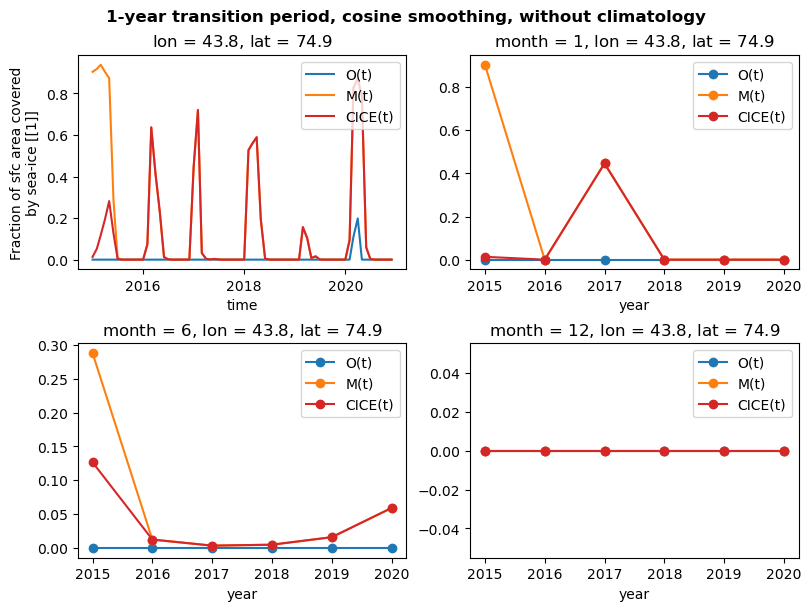

In [218]:
ny = '1'
fig, ax = plot_single_gridcell(
    obs_cice_overlap,
    lens_cice_overlap,
    cice_relax['time']['t'][ny],
    obs_cice_overlap_my,
    lens_cice_overlap_my,
    cice_relax['time']['my'][ny],
    ilat=175, ilon=35, tag='CICE'
)
fig.suptitle(f'{ny}-year transition period, cosine smoothing, without climatology', fontweight='bold')

Text(0.5, 0.98, '1-year transition period, cosine smoothing, with climatology')

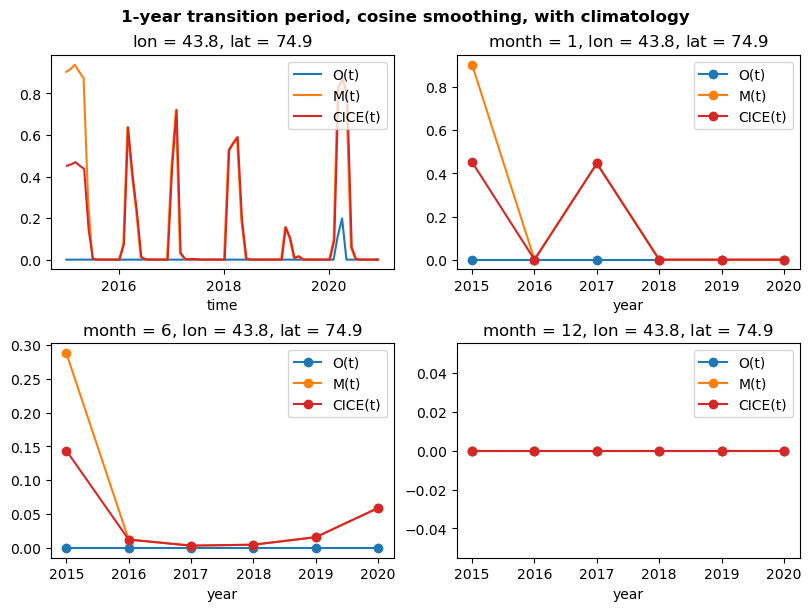

In [217]:
ny = '1'
fig, ax = plot_single_gridcell(
    obs_cice_overlap,
    lens_cice_overlap,
    cice_relax['clim']['t'][ny],
    obs_cice_overlap_my,
    lens_cice_overlap_my,
    cice_relax['clim']['my'][ny],
    ilat=175, ilon=35, tag='CICE'
)
fig.suptitle(f'{ny}-year transition period, cosine smoothing, with climatology', fontweight='bold')

## regional plots

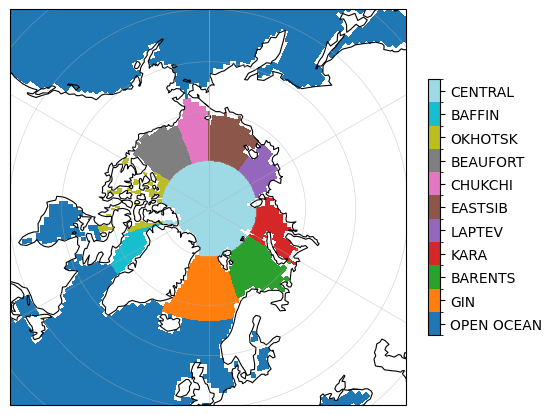

In [ ]:
# https://www.gfdl.noaa.gov/arctic-sea-ice-predictions/
lat_bnds = [67, 80]
cice_regions = {
    'gin': [335, 18],
    'barents': [18, 57],
    'kara': [57, 103],
    'laptev': [103, 143],
    'eastsib': [143, 180],
    'chukchi': [180, 200],
    'beaufort': [200, 235],
    'okhotsk': [235, 287],
    'baffin': [287, 320],
    'central': [-1, 360],
}


lat = area.lat
lon = area.lon
cice_iregmask = xr.zeros_like(area, dtype=np.int16)
region_ids = {}

for ireg, (name, lon_bnds) in enumerate(cice_regions.items(), start=1):
    if lon_bnds[0] > lon_bnds[1]:
        # where longitude crosses prime meridian
        in_region = (
            (lat > lat_bnds[0])
            & (lat <= lat_bnds[1])
            & ((lon > lon_bnds[0]) | (lon <= lon_bnds[1]))
        )
    elif lon_bnds[0] < 0:
        # central region north of 80N
        in_region = (
            (lat > lat_bnds[1])
            & (lon > lon_bnds[0])
            & (lon <= lon_bnds[1])
        )
    else:
        in_region = (
            (lat > lat_bnds[0])
            & (lat <= lat_bnds[1])
            & (lon > lon_bnds[0])
            & (lon <= lon_bnds[1])
        )

    # Assign region ID where condition is true; 0 remains outside all regions.
    cice_iregmask = xr.where(in_region, ireg, cice_iregmask)
    region_ids[name] = ireg

ireg += 1
in_region = (
    (lat > lat_bnds[1])
    & (lon >= 0)
    & (lon < 360)
)
cice_iregmask = xr.where(in_region, ireg , cice_iregmask)
region_ids['central'] = ireg

fig = plt.figure(figsize=(10, 8), dpi=100, layout='constrained')
ax = fig.add_subplot(2, 2, 1, projection=ccrs.NorthPolarStereo())

# Build integer->name lookup from region_ids for labeled colorbar ticks.
id_to_name = {0: 'open ocean'}
id_to_name.update({idx: name for name, idx in region_ids.items()})
labels = sorted(id_to_name.keys())
nlab = len(labels)

# Discrete colormap with one color per integer label, including 0 for open ocean.
cmap = plt.get_cmap('tab20', nlab)
norm = mcolors.BoundaryNorm(np.arange(-0.5, labels[-1] + 1.5, 1), cmap.N)

p = cice_iregmask.where(om).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={'fraction': 0.03, 'ticks': labels},
)

# Replace numeric ticks with region names.
cbar = p.colorbar
cbar.set_ticklabels([id_to_name[i].upper() for i in labels])

ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.set_title('')
ax.coastlines(linewidth=0.8, color='black')
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

Text(0.5, 0.98, '3-year transition period, cosine smoothing, without climatology, month = 9')

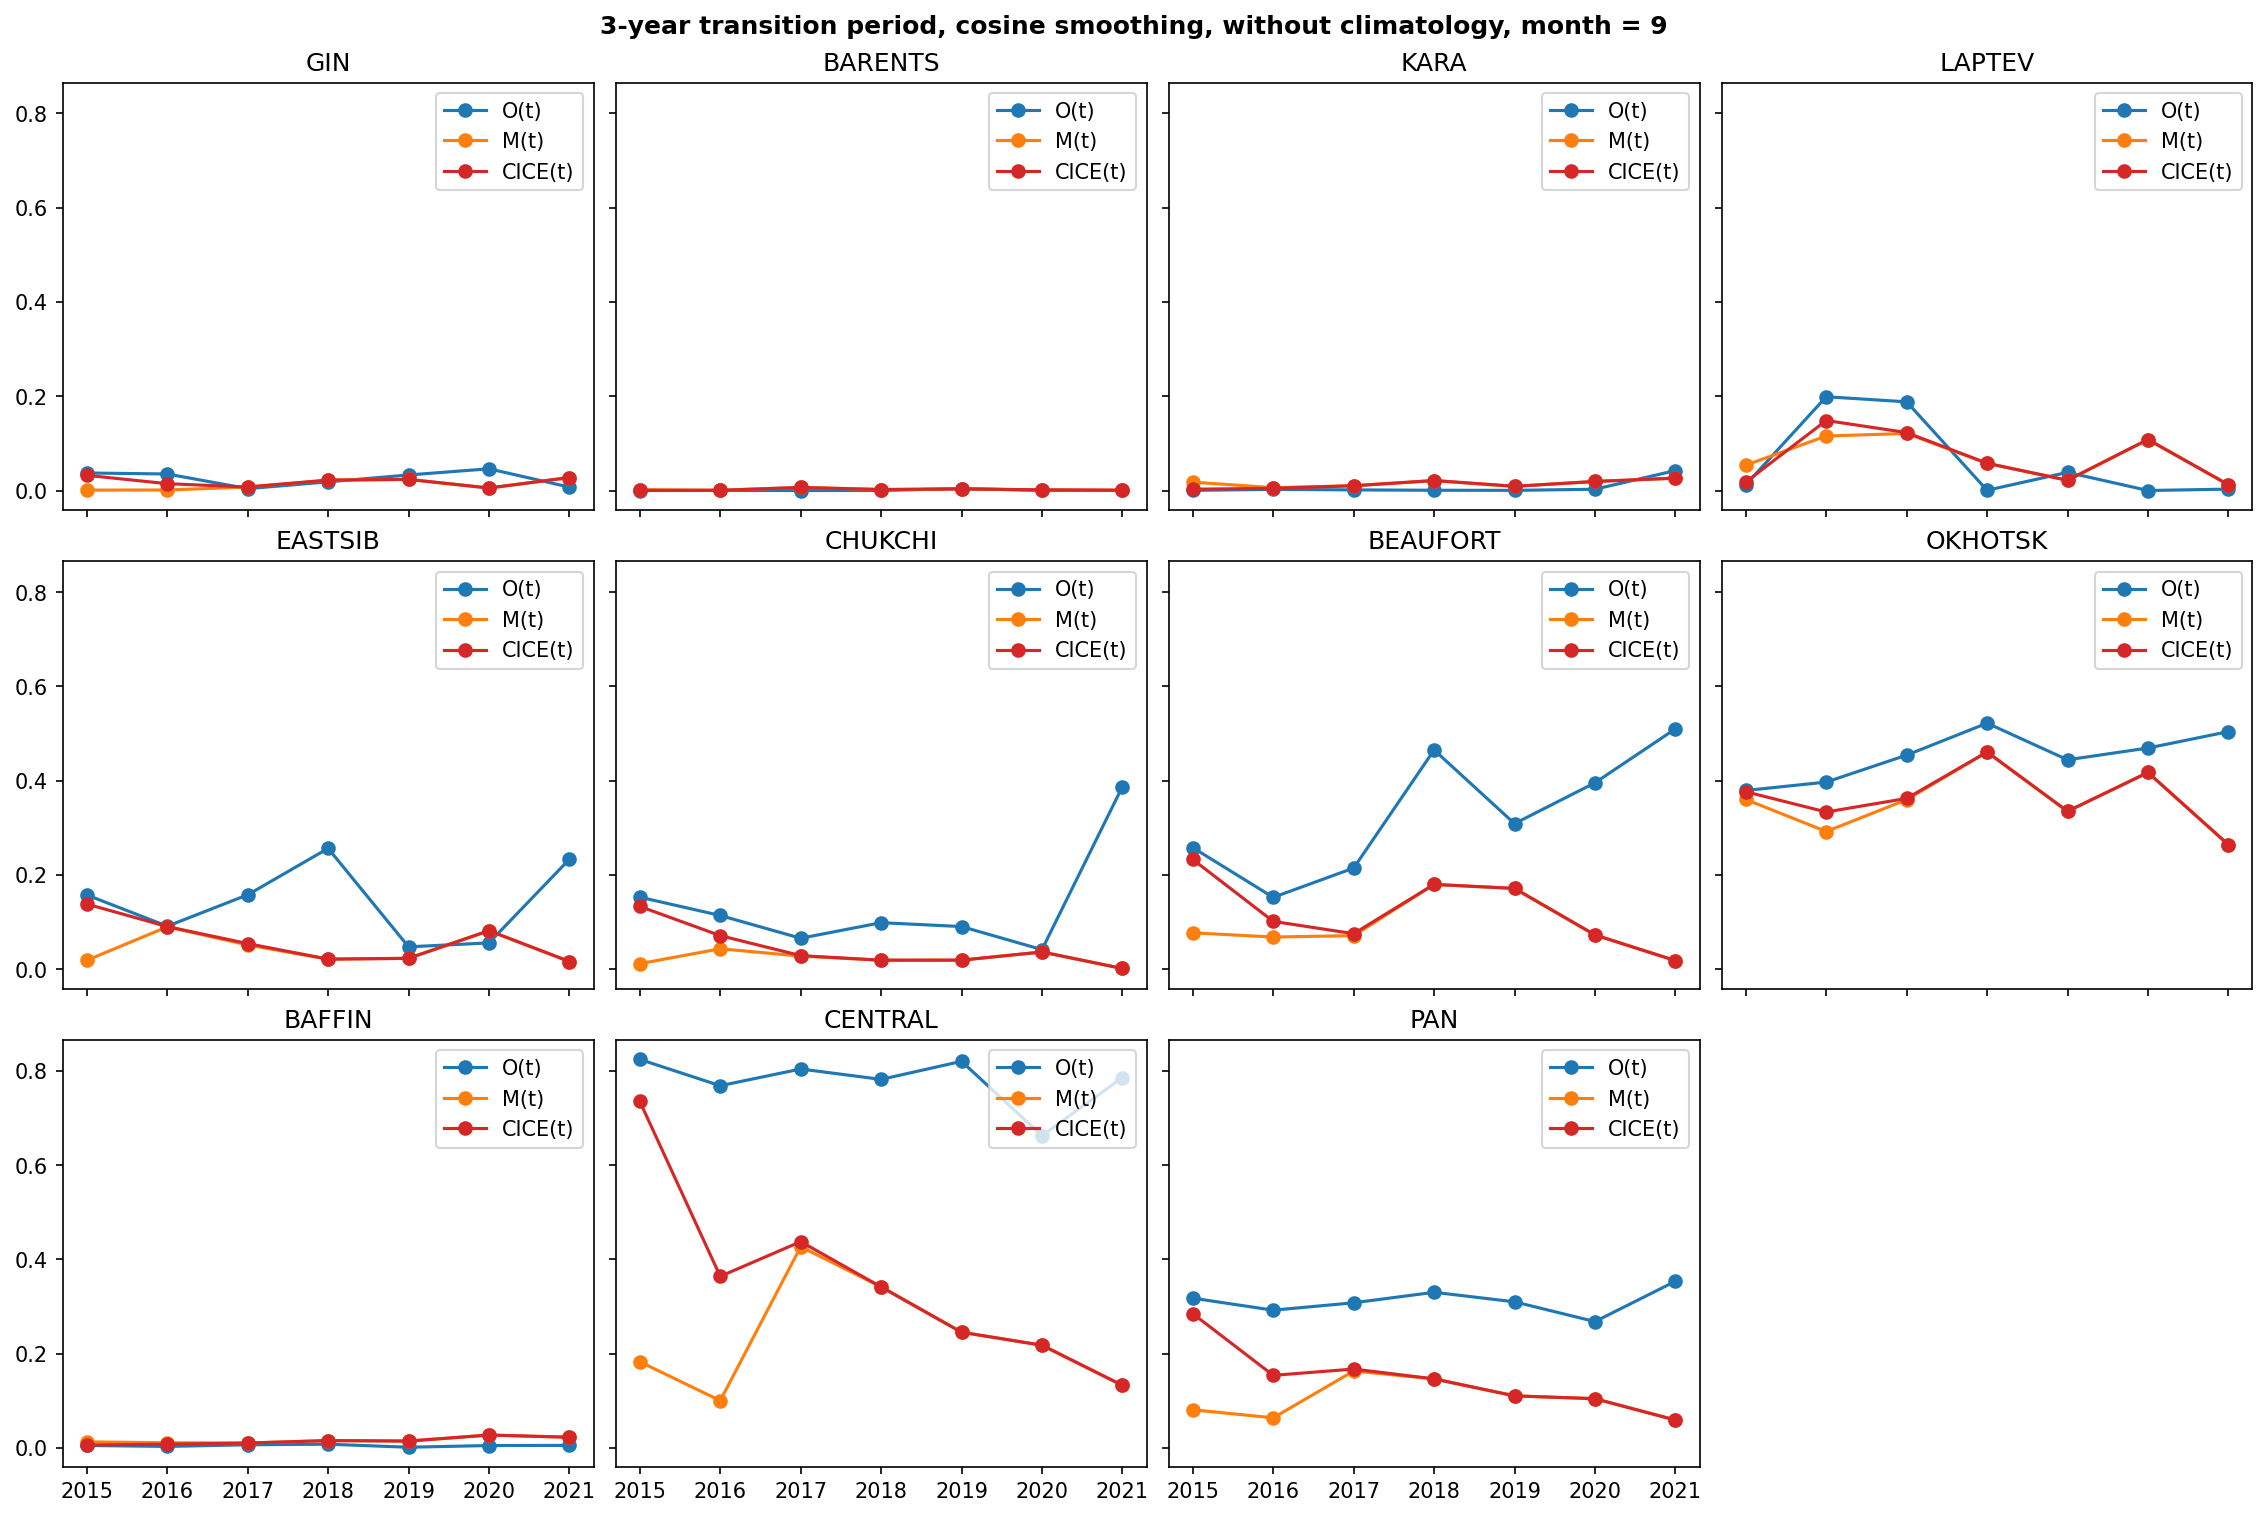

In [ ]:
ny = '1'
im = 8
yrs = slice(2015, 2021)

fig, axs = plt.subplots(3, 4, figsize=(15, 10), sharex=True, sharey=True, layout='constrained', dpi=150)
ax = axs.flatten()

for name, i in region_ids.items():
    obs_cice_overlap_my.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)', marker='o')
    lens_cice_overlap_my.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)', marker='o')
    cice_relax['time']['my'][ny].isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)', marker='o')
    ax[i-1].set_xlabel('')
    ax[i-1].set_ylabel('')
    ax[i-1].legend(loc='upper right')
    ax[i-1].set_title(name.upper())

i += 1
obs_cice_overlap_my.isel(month=im).sel(year=yrs).where(obs_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)', marker='o')
lens_cice_overlap_my.isel(month=im).sel(year=yrs).where(lens_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)', marker='o')
cice_relax['time']['my'][ny].isel(month=im).sel(year=yrs).where(cice_relax['time']['my'][ny].lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)', marker='o')
ax[i-1].set_xlabel('')
ax[i-1].set_ylabel('')
ax[i-1].legend(loc='upper right')
ax[i-1].set_title('PAN')

ax[-1].remove()

plt.suptitle(f'{ny}-year transition period, cosine smoothing, without climatology, month = {im+1}', fontweight='bold')

Text(0.5, 0.98, '1-year transition period, cosine smoothing, without climatology, mean sea ice fraction')

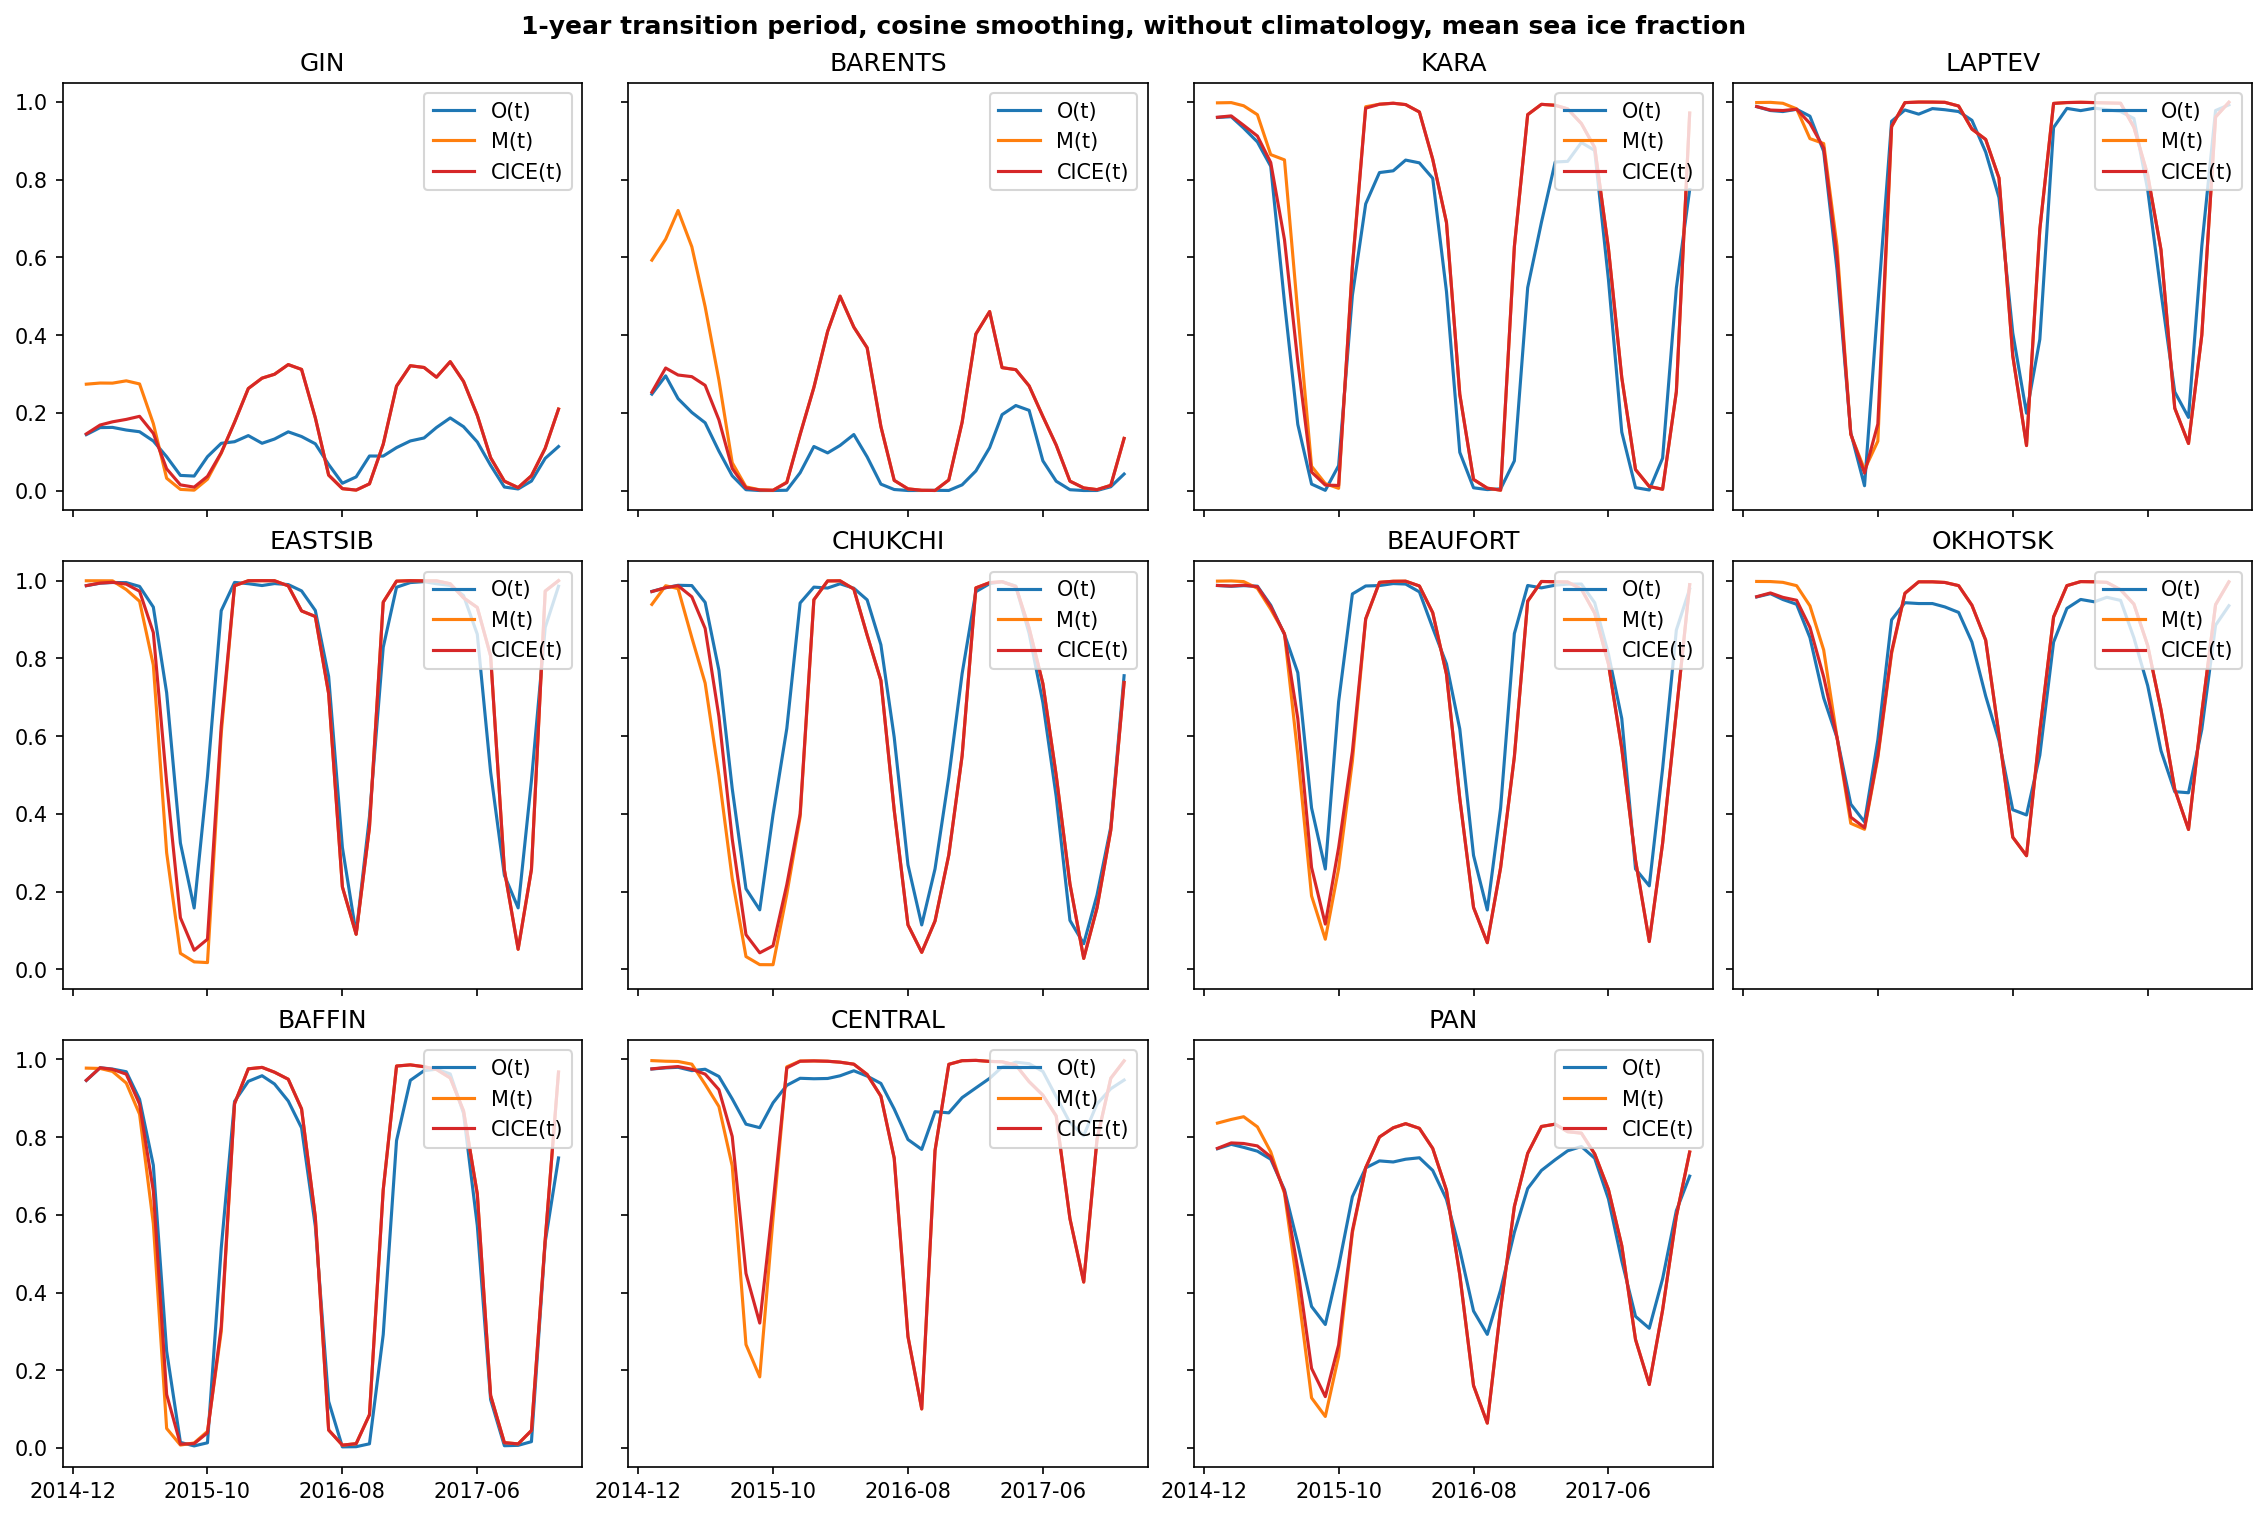

In [214]:
ny = '1'
time_slice = slice('2015', '2017')

fig, axs = plt.subplots(3, 4, figsize=(15, 10), sharex=True, sharey=True, layout='constrained', dpi=150)
ax = axs.flatten()

for name, i in region_ids.items():
    obs_cice_overlap.sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
    lens_cice_overlap.sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
    cice_relax['time']['t'][ny].sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
    ax[i-1].set_xlabel('')
    ax[i-1].set_ylabel('')
    ax[i-1].legend(loc='upper right')
    ax[i-1].set_title(name.upper())

i += 1
obs_cice_overlap.sel(time=time_slice).where(obs_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
lens_cice_overlap.sel(time=time_slice).where(lens_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
cice_relax['time']['t'][ny].sel(time=time_slice).where(cice_relax['time']['t'][ny].lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
ax[i-1].set_xlabel('')
ax[i-1].set_ylabel('')
ax[i-1].legend(loc='upper right')
ax[i-1].set_title('PAN')

ax[-1].remove()

plt.suptitle(f'{ny}-year transition period, cosine smoothing, without climatology, mean sea ice fraction', fontweight='bold')

In [ ]:
ny = '1'
im = 8
yrs = slice(2015, 2021)

fig, axs = plt.subplots(3, 4, figsize=(15, 10), sharex=True, sharey=True, layout='constrained', dpi=150)
ax = axs.flatten()

for name, i in region_ids.items():
    obs_cice_overlap_my.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)', marker='o')
    lens_cice_overlap_my.isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)', marker='o')
    cice_relax['clim']['my'][ny].isel(month=im).sel(year=yrs).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)', marker='o')
    ax[i-1].set_xlabel('')
    ax[i-1].set_ylabel('')
    ax[i-1].legend(loc='upper right')
    ax[i-1].set_title(name.upper())

i += 1
obs_cice_overlap_my.isel(month=im).sel(year=yrs).where(obs_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)', marker='o')
lens_cice_overlap_my.isel(month=im).sel(year=yrs).where(lens_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)', marker='o')
cice_relax['clim']['my'][ny].isel(month=im).sel(year=yrs).where(cice_relax['time']['my'][ny].lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)', marker='o')
ax[i-1].set_xlabel('')
ax[i-1].set_ylabel('')
ax[i-1].legend(loc='upper right')
ax[i-1].set_title('PAN')

ax[-1].remove()

plt.suptitle(f'{ny}-year transition period, cosine smoothing, with climatology, month = {im+1}', fontweight='bold')

Text(0.5, 0.98, '2-year transition period, cosine smoothing, with climatology, mean sea ice fraction')

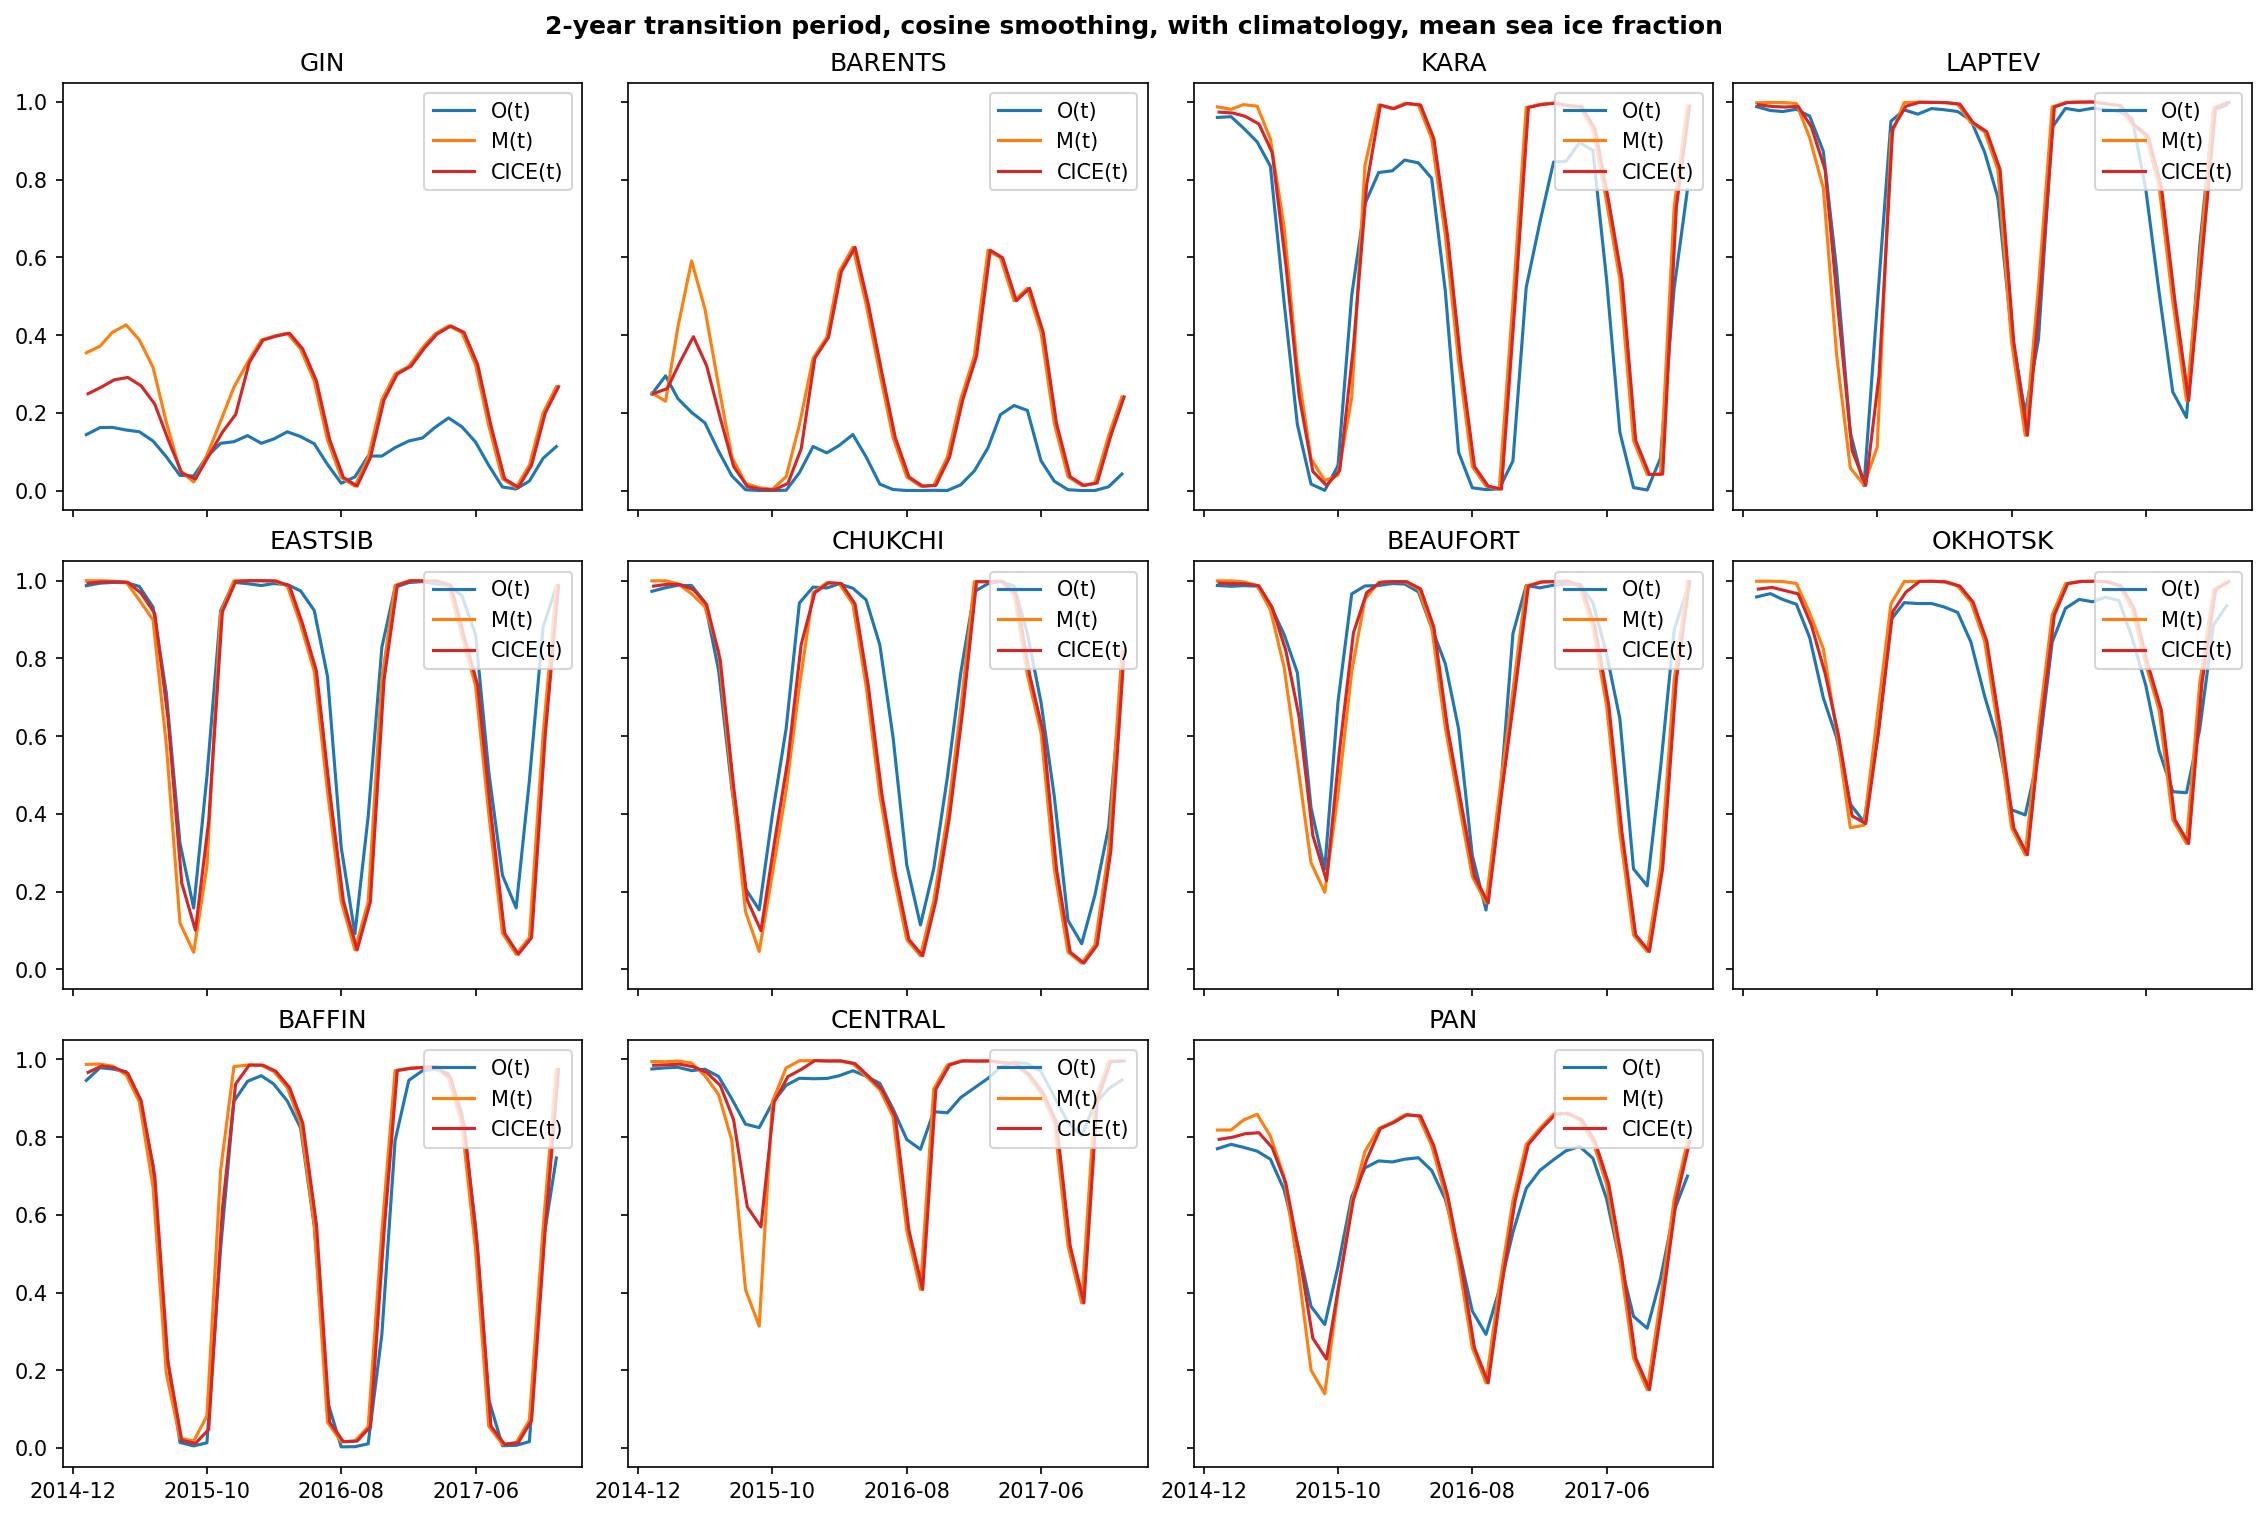

In [200]:
time_slice = slice('2015', '2017')

fig, axs = plt.subplots(3, 4, figsize=(15, 10), sharex=True, sharey=True, layout='constrained', dpi=150)
ax = axs.flatten()

for name, i in region_ids.items():
    obs_cice_overlap.sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
    lens_cice_overlap.sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
    cice_overlap_clim.sel(time=time_slice).where(cice_iregmask == i).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
    ax[i-1].set_xlabel('')
    ax[i-1].set_ylabel('')
    ax[i-1].legend(loc='upper right')
    ax[i-1].set_title(name.upper())

i += 1
obs_cice_overlap.sel(time=time_slice).where(obs_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:blue', label='O(t)')
lens_cice_overlap.sel(time=time_slice).where(lens_cice_overlap_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:orange', label='M(t)')
cice_overlap_clim.sel(time=time_slice).where(cice_overlap_time_my.lat > lat_bnds[0]).weighted(oa.fillna(0)).mean(dim=['lat', 'lon']).plot(ax=ax[i-1], c='tab:red', label='CICE(t)')
ax[i-1].set_xlabel('')
ax[i-1].set_ylabel('')
ax[i-1].legend(loc='upper right')
ax[i-1].set_title('PAN')

ax[-1].remove()

plt.suptitle(f'2-year transition period, cosine smoothing, with climatology, mean sea ice fraction', fontweight='bold')